# Company X Loan Approval Pre-Screening

**Project Objective:** Xây dựng giải pháp Machine Learning hoàn chỉnh nhằm phân tích dữ liệu lịch sử phê duyệt khoản vay và đề xuất mô hình dự đoán phù hợp, hỗ trợ Company X nâng cao hiệu quả sàng lọc hồ sơ vay vốn.

**Course:** FDC104 - Lập trình cho phân tích dữ liệu và tính toán khoa học

**Version:** Final

**Submission Date:** 12/07/2026

**Project Team**: Nhóm 1

| # | Owner | Role |
|---|---|---|
| 1 | Nguyen Thi Mai Anh | Project Lead & Finalization |
| 2 | Le Yen Chi | EDA & Visualization Lead |
| 3 | Tran Thi Ha Thuong | Data Preparation Lead |
| 4 | Nguyen Tu Anh | Machine Learning Lead |
| 5 | Nguyen Nhat Huy | Business Strategy & Interpretation Lead |

## Notebook Overview

Notebook trình bày quy trình Machine Learning hoàn chỉnh nhằm phân tích dữ liệu lịch sử và xây dựng mô hình dự đoán hỗ trợ Company X trong quá trình phê duyệt khoản vay mua nhà.

**Workflow**

Business Understanding → Data Understanding → Data Quality Assessment → Exploratory Data Analysis → Feature Engineering → Data Preprocessing → Model Development → Model Evaluation → Business Recommendation

Ba mô hình học máy có giám sát gồm **Logistic Regression, Decision Tree và Random Forest** được xây dựng và so sánh nhằm đánh giá sự cân bằng giữa hiệu quả dự đoán, khả năng giải thích mô hình và tính ứng dụng trong thực tiễn doanh nghiệp.

# 1. Business Understanding

## 1.1 Business Context

Company X cung cấp dịch vụ cho vay mua nhà cho khách hàng tại khu vực thành thị, bán đô thị và nông thôn. Khi số lượng hồ sơ vay ngày càng tăng, quy trình sàng lọc thủ công trở nên tốn nhiều thời gian và có thể dẫn đến sự thiếu nhất quán trong quá trình ra quyết định.

Để nâng cao hiệu quả vận hành, công ty mong muốn khai thác dữ liệu lịch sử các hồ sơ vay nhằm hỗ trợ quy trình sàng lọc tự động. Mục tiêu của giải pháp không phải thay thế chuyên viên tín dụng mà hỗ trợ ưu tiên xử lý hồ sơ và rút ngắn thời gian đánh giá ban đầu.

## 1.2 Business Problem

Nếu chưa áp dụng quy trình sàng lọc dựa trên dữ liệu, Company X có thể gặp phải:

- Thời gian xử lý hồ sơ kéo dài.
- Quyết định phê duyệt thiếu nhất quán.
- Tốn nhiều nguồn lực cho việc đánh giá các hồ sơ có mức độ rủi ro thấp.

**Business Question**

> Làm thế nào có thể tận dụng dữ liệu lịch sử các hồ sơ vay để hỗ trợ quy trình sàng lọc hồ sơ nhanh hơn và nhất quán hơn?

## 1.3 Business Objective

Dự án hướng đến các mục tiêu sau:

- Phân tích dữ liệu lịch sử các hồ sơ vay.
- Xác định các yếu tố có liên quan đến quyết định phê duyệt khoản vay.
- Xây dựng các mô hình Machine Learning có khả năng giải thích để hỗ trợ sàng lọc hồ sơ vay.
- So sánh các mô hình trên cả hai khía cạnh: hiệu quả dự đoán và giá trị ứng dụng trong kinh doanh.
- Đề xuất mô hình phù hợp cho các nhu cầu vận hành khác nhau của doanh nghiệp.

**Scope Note**

> Dự án dự đoán quyết định phê duyệt khoản vay trong dữ liệu lịch sử, không dự đoán rủi ro vỡ nợ của khách hàng. Vì vậy, các kết quả phản ánh mối liên hệ thống kê giữa các biến, không khẳng định quan hệ nhân quả.

## 1.4 Business Questions

| Business Question | Purpose |
|---|---|
| Q1. Khách hàng vay vốn điển hình là ai? | Hiểu đặc điểm chung của nhóm khách hàng |
| Q2. Những đặc điểm nào của khách hàng có liên quan đến quyết định phê duyệt? | Xác định các yếu tố nhân khẩu học quan trọng |
| Q3. Các yếu tố tài chính ảnh hưởng như thế nào đến quyết định phê duyệt? | Đánh giá khả năng chi trả của khách hàng |
| Q4. Lịch sử tín dụng có phải là yếu tố quan trọng nhất không? | Kiểm chứng kết quả từ EDA và mô hình |
| Q5. Mô hình nào phù hợp nhất với nhu cầu của doanh nghiệp? | So sánh hiệu quả dự đoán và khả năng ứng dụng |

### Expected Business Outcome

Sau khi hoàn thành dự án, Company X có thể:

- Hiểu rõ hơn các đặc điểm của những hồ sơ đã được phê duyệt trong quá khứ.
- Xác định các yếu tố quan trọng ảnh hưởng đến quyết định phê duyệt khoản vay.
- Lựa chọn mô hình dự đoán phù hợp với mục tiêu và nhu cầu vận hành của doanh nghiệp.


In [1]:
# Standard Library
from pathlib import Path

# Third-party Library
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display

In [2]:
sns.set_theme(style="whitegrid", palette="Blues")

chart_palette = sns.color_palette("Blues", 6)
approved_color = chart_palette[4]
rejected_color = chart_palette[2]

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

In [3]:
def calculate_approval_rate(data, group_column):
    approval_rate = (
        data.groupby(group_column, dropna=False)["Loan_Status"]
        .agg(
            application_count="size",
            approved_count=lambda status: status.eq("Y").sum(),
            approval_rate=lambda status: status.eq("Y").mean() * 100
        )
        .reset_index()
    )

    approval_rate[group_column] = (
        approval_rate[group_column]
        .astype("object")
        .where(approval_rate[group_column].notna(), "Missing")
    )

    return approval_rate


def show_insight(observation, interpretation, business_implication):
    insight_text = (
        f"**Observation.** {observation}\n\n"
        f"**Interpretation.** {interpretation}\n\n"
        f"**Business Implication.** {business_implication}"
    )
    display(Markdown(insight_text))


def plot_approval_rate(approval_rate, group_column, title, xlabel):
    figure, axis = plt.subplots(figsize=(8, 5))

    sns.barplot(
        data=approval_rate,
        x=group_column,
        y="approval_rate",
        color=approved_color,
        ax=axis
    )

    axis.set_title(title, fontsize=13, weight="bold")
    axis.set_xlabel(xlabel)
    axis.set_ylabel("Approval rate (%)")
    axis.set_ylim(0, 100)

    for container in axis.containers:
        axis.bar_label(container, fmt="%.1f%%", padding=3)

    plt.tight_layout()
    plt.show()

# 2. Dataset Understanding

## 2.1 Dataset Overview

Bộ dữ liệu gồm **614 hồ sơ** vay mua nhà trong lịch sử của Company X.

Mỗi dòng dữ liệu tương ứng với một hồ sơ vay, bao gồm thông tin nhân khẩu học của khách hàng, đặc điểm tài chính, thông tin khoản vay, lịch sử tín dụng và kết quả phê duyệt khoản vay.

Bộ dữ liệu này là cơ sở để phân tích các yếu tố ảnh hưởng đến quyết định phê duyệt và xây dựng các mô hình dự đoán nhằm hỗ trợ quy trình sàng lọc hồ sơ vay.

In [4]:
data_path = Path("company-x-loan.csv")

if not data_path.exists():
    raise FileNotFoundError(
        "Place company-x-loan.csv in the same folder as this notebook before running it."
    )

df = pd.read_csv(data_path)

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

dataset_overview = pd.DataFrame({
    "Metric": [
        "Number of loan applications",
        "Number of variables",
        "Numeric variables",
        "Categorical variables",
        "Target variable"
    ],
    "Value": [
        len(df),
        df.shape[1],
        len(numeric_columns),
        len(categorical_columns),
        "Loan_Status"
    ]
})

dataset_overview

,Metric,Value
0,Number of loan applications,614
1,Number of variables,13
2,Numeric variables,5
3,Categorical variables,8
4,Target variable,Loan_Status


In [5]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.00,NaN,360.00,1.00,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,"1,508.00",128.00,360.00,1.00,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.00,66.00,360.00,1.00,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,"2,358.00",120.00,360.00,1.00,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.00,141.00,360.00,1.00,Urban,Y


### Target Variable

Biến mục tiêu

Loan_Status là biến mục tiêu của mô hình.

- Y → Hồ sơ được phê duyệt
- N → Hồ sơ bị từ chối

Mục tiêu của dự án là dự đoán quyết định phê duyệt khoản vay trong dữ liệu lịch sử dựa trên các thông tin của khách hàng tại thời điểm nộp hồ sơ.

In [6]:
data_dictionary = pd.DataFrame([
    ["Loan_ID", "Identifier", "Unique loan application ID", "Identifier only"],
    ["Gender", "Categorical", "Applicant gender", "Applicant profile"],
    ["Married", "Categorical", "Applicant marital status", "Applicant profile"],
    ["Dependents", "Categorical", "Number of dependents, including '3+'", "Applicant profile"],
    ["Education", "Categorical", "Graduate or Not Graduate", "Applicant profile"],
    ["Self_Employed", "Categorical", "Self-employed status", "Applicant profile"],
    ["ApplicantIncome", "Numeric", "Applicant income", "Financial profile"],
    ["CoapplicantIncome", "Numeric", "Co-applicant income", "Financial profile"],
    ["LoanAmount", "Numeric", "Loan amount in thousands", "Financial profile"],
    ["Loan_Amount_Term", "Numeric", "Loan term in months", "Financial profile"],
    ["Credit_History", "Binary / Numeric", "Whether credit history meets guidelines", "Credit profile"],
    ["Property_Area", "Categorical", "Urban, Semiurban, or Rural", "Property profile"],
    ["Loan_Status", "Categorical target", "Historical loan decision: Y or N", "Target"]
], columns=["Column", "Data Type", "Business Meaning", "Analytical Role"])

data_dictionary

,Column,Data Type,Business Meaning,Analytical Role
0,Loan_ID,Identifier,Unique loan application ID,Identifier only
1,Gender,Categorical,Applicant gender,Applicant profile
2,Married,Categorical,Applicant marital status,Applicant profile
3,Dependents,Categorical,"Number of dependents, including '3+'",Applicant profile
4,Education,Categorical,Graduate or Not Graduate,Applicant profile
5,Self_Employed,Categorical,Self-employed status,Applicant profile
6,ApplicantIncome,Numeric,Applicant income,Financial profile
7,CoapplicantIncome,Numeric,Co-applicant income,Financial profile
8,LoanAmount,Numeric,Loan amount in thousands,Financial profile
9,Loan_Amount_Term,Numeric,Loan term in months,Financial profile


> **Note**
> 
> Loan_ID là mã định danh duy nhất của từng hồ sơ vay, chỉ phục vụ mục đích nhận diện và truy xuất dữ liệu. Vì không mang thông tin hỗ trợ dự đoán kết quả phê duyệt, biến này sẽ được loại khỏi tập đặc trưng trong quá trình tiền xử lý.

### Conclusion

Sau khi hiểu rõ cấu trúc và các biến của bộ dữ liệu, bước tiếp theo là đánh giá chất lượng dữ liệu bằng cách kiểm tra giá trị thiếu, dữ liệu trùng lặp và các vấn đề tiềm ẩn nhằm đảm bảo dữ liệu sẵn sàng cho các bước phân tích và xây dựng mô hình.

## 2.2 Descriptive Profile

### 2.2.1 Numeric Variables Summary

In [7]:
numeric_columns = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term"
]

numeric_summary = df[numeric_columns].describe().T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.00,"5,403.46","6,109.04",150.00,"2,877.50","3,812.50","5,795.00","81,000.00"
CoapplicantIncome,614.00,"1,621.25","2,926.25",0.00,0.00,"1,188.50","2,297.25","41,667.00"
LoanAmount,592.00,146.41,85.59,9.00,100.00,128.00,168.00,700.00
Loan_Amount_Term,600.00,342.00,65.12,12.00,360.00,360.00,360.00,480.00


#### Initial Observations

- Thu nhập của khách hàng biến động đáng kể giữa các hồ sơ vay, phản ánh sự đa dạng về năng lực tài chính của người vay.
- Giá trị khoản vay có mức độ phân tán thấp hơn so với thu nhập, cho thấy các khoản vay được cấp trong một khoảng giá trị tương đối ổn định.
- Đa số các khoản vay có thời hạn 360 tháng, cho thấy Company X chủ yếu áp dụng một kỳ hạn vay tiêu chuẩn cho sản phẩm này.

### 2.2.2 Credit History Overview

In [8]:
# Credit History summary
credit_summary = (
    df["Credit_History"]
    .value_counts(dropna=False)
    .rename_axis("Credit_History")
    .reset_index(name="Count")
)

# Percentage
credit_summary["Percentage"] = (
    credit_summary["Count"] /
    credit_summary["Count"].sum() * 100
).round(1)

# Rename values for business readability
credit_summary["Credit_History"] = (
    credit_summary["Credit_History"]
    .replace({
        1.0: "Has Credit History",
        0.0: "No Credit History"
    })
    .fillna("Missing")
)

credit_summary

,Credit_History,Count,Percentage
0,Has Credit History,475,77.40
1,No Credit History,89,14.50
2,Missing,50,8.10


#### Interpretation

Biến **Credit_History** là biến nhị phân, trong đó **1** biểu thị khách hàng có lịch sử tín dụng đạt yêu cầu, còn **0** biểu thị khách hàng không đáp ứng điều kiện này.

Từ thống kê mô tả có thể thấy:

- **77,4%** khách hàng có lịch sử tín dụng đạt yêu cầu.
- **14,5%** khách hàng không có lịch sử tín dụng đạt yêu cầu.
- **8,1%** hồ sơ thiếu thông tin Credit_History và sẽ được xử lý ở bước tiền xử lý dữ liệu.

Ở giai đoạn này, kết quả trên chỉ phản ánh phân bố của biến. Mức độ ảnh hưởng của Credit_History đến quyết định phê duyệt khoản vay sẽ được đánh giá chi tiết hơn trong phần Phân tích khám phá dữ liệu (EDA) và Phát triển mô hình.

### 2.2.3 Categorical Variables Summary

In [9]:
categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

categorical_summary = (
    df[categorical_columns]
    .describe()
    .T
    .rename(columns={"top": "most_frequent_value", "freq": "most_frequent_count"})
)

categorical_summary

,count,unique,most_frequent_value,most_frequent_count
Gender,601,2,Male,489
Married,611,2,Yes,398
Dependents,599,4,0,345
Education,614,2,Graduate,480
Self_Employed,582,2,No,500
Property_Area,614,3,Semiurban,233
Loan_Status,614,2,Y,422


#### Initial Observations

- Phần lớn các biến phân loại chỉ có 2–3 nhóm giá trị, phù hợp với các phương pháp mã hóa như Label Encoding và One-Hot Encoding trong bước tiền xử lý.
- Hồ sơ vay trong bộ dữ liệu chủ yếu thuộc nhóm khách hàng nam giới, đã kết hôn và tốt nghiệp đại học.
- Biến mục tiêu `Loan_Status` có mức độ mất cân bằng không lớn, với các hồ sơ được phê duyệt chiếm đa số.

#### Business Implication

- Thống kê mô tả giúp Company X có cái nhìn tổng quan về đặc điểm khách hàng và các khoản vay trong dữ liệu lịch sử trước khi thực hiện tiền xử lý và xây dựng mô hình.
- Phần lớn khách hàng trong bộ dữ liệu có lịch sử tín dụng đạt yêu cầu, cho thấy các hồ sơ lịch sử chủ yếu thuộc nhóm đáp ứng các điều kiện vay cơ bản.
- Đồng thời, bộ dữ liệu bao gồm nhiều biến phân loại, số lượng biến tài chính còn hạn chế và một số trường dữ liệu vẫn tồn tại giá trị thiếu. Vì vậy, việc mã hóa dữ liệu và xử lý các giá trị thiếu là những bước tiền xử lý quan trọng nhằm đảm bảo mô hình được huấn luyện trên dữ liệu nhất quán và đáng tin cậy.

# 3. Data Quality Assessment

## 3.1 Missing Values

### Business Question
Những trường dữ liệu nào chứa giá trị thiếu cần được xử lý để đảm bảo độ tin cậy cho quá trình phân tích và phát triển mô hình?


In [10]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_rate": df.isna().mean() * 100
}).reset_index().rename(columns={"index": "column"})

missing_summary = missing_summary.sort_values(
    by=["missing_count", "column"],
    ascending=[False, True]
).reset_index(drop=True)

missing_summary

,column,missing_count,missing_rate
0,Credit_History,50,8.14
1,Self_Employed,32,5.21
2,LoanAmount,22,3.58
3,Dependents,15,2.44
4,Loan_Amount_Term,14,2.28
5,Gender,13,2.12
6,Married,3,0.49
7,ApplicantIncome,0,0.00
8,CoapplicantIncome,0,0.00
9,Education,0,0.00


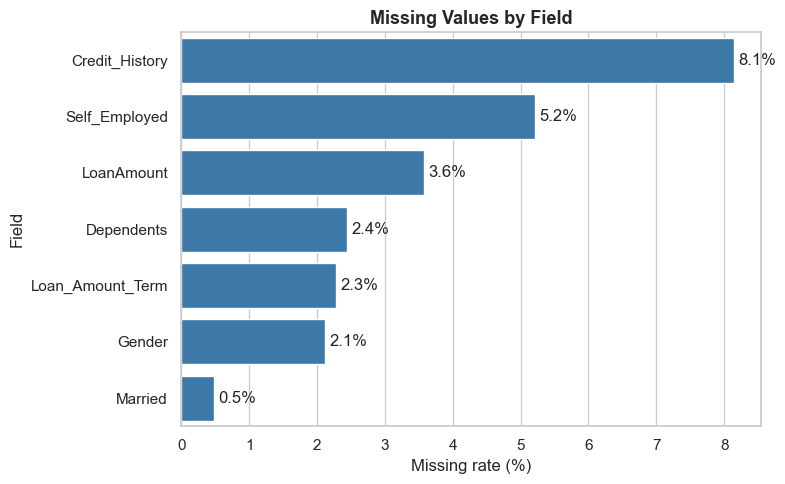

In [11]:
missing_issues = missing_summary.query("missing_count > 0").copy()

figure, axis = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=missing_issues,
    x="missing_rate",
    y="column",
    color=chart_palette[4],
    ax=axis
)

axis.set_title("Missing Values by Field", fontsize=13, weight="bold")
axis.set_xlabel("Missing rate (%)")
axis.set_ylabel("Field")

for container in axis.containers:
    axis.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

In [12]:
highest_missing_field = missing_summary.iloc[0]["column"]
highest_missing_rate = missing_summary.iloc[0]["missing_rate"]

show_insight(
    observation=(
        f"{highest_missing_field} có tỷ lệ thiếu dữ liệu cao nhất "
        f"({highest_missing_rate:.1f}%), tiếp theo là `Self_Employed` và `LoanAmount`."
        " Đây là các biến có thể ảnh hưởng đến việc đánh giá hồ sơ tín dụng và đặc điểm khoản vay của khách hàng."
    ),
    interpretation=(
        "Dữ liệu tổng thể có mức độ đầy đủ khá tốt, tuy nhiên dữ liệu thiếu tập trung vào một số trường thông tin quan trọng liên quan đến khả năng đánh giá rủi ro và quyết định cấp vay."
    ),
    business_implication=(
        "Cần xây dựng quy tắc xử lý dữ liệu thiếu nhất quán trước khi thực hiện mô hình hóa. Đặc biệt, `Credit_History` cần được xử lý cẩn trọng vì đây là yếu tố quan trọng trong đánh giá mức độ tín nhiệm của khách hàng."
    )
)

**Observation.** Credit_History có tỷ lệ thiếu dữ liệu cao nhất (8.1%), tiếp theo là `Self_Employed` và `LoanAmount`. Đây là các biến có thể ảnh hưởng đến việc đánh giá hồ sơ tín dụng và đặc điểm khoản vay của khách hàng.

**Interpretation.** Dữ liệu tổng thể có mức độ đầy đủ khá tốt, tuy nhiên dữ liệu thiếu tập trung vào một số trường thông tin quan trọng liên quan đến khả năng đánh giá rủi ro và quyết định cấp vay.

**Business Implication.** Cần xây dựng quy tắc xử lý dữ liệu thiếu nhất quán trước khi thực hiện mô hình hóa. Đặc biệt, `Credit_History` cần được xử lý cẩn trọng vì đây là yếu tố quan trọng trong đánh giá mức độ tín nhiệm của khách hàng.

## 3.2 Duplicate Records and Identifier Validation

### Business Question
Các bản ghi bị trùng lặp hoặc mã định danh khoản vay không duy nhất có cho thấy rủi ro tiềm ẩn về tính toàn vẹn dữ liệu hay không?

In [13]:
duplicate_summary = pd.DataFrame({
    "Check": [
        "Fully duplicated rows",
        "Duplicated Loan_ID values",
        "Unique Loan_ID values"
    ],
    "Result": [
        int(df.duplicated().sum()),
        int(df["Loan_ID"].duplicated().sum()),
        int(df["Loan_ID"].nunique())
    ]
})

duplicate_summary

,Check,Result
0,Fully duplicated rows,0
1,Duplicated Loan_ID values,0
2,Unique Loan_ID values,614


In [14]:
show_insight(
    observation=(
        f"The raw dataset contains {int(df.duplicated().sum())} bản ghi trùng lặp và "
        f"{int(df['Loan_ID'].duplicated().sum())} biến `Loan_ID values` trùng lặp."
    ),
    interpretation=(
        "Mỗi dòng dữ liệu đại diện cho một hồ sơ vay riêng biệt, đồng thời trường định danh `Loan_ID` đảm bảo tính duy nhất."
    ),
    business_implication=(
        "Có thể sử dụng toàn bộ dữ liệu lịch sử cho các bước phân tích tiếp theo. `Loan_ID` nên được giữ lại để phục vụ mục đích kiểm tra và truy vết dữ liệu, nhưng không nên đưa vào mô hình dự báo vì không phản ánh đặc điểm hoặc khả năng đủ điều kiện vay của khách hàng."
    )
)

**Observation.** The raw dataset contains 0 bản ghi trùng lặp và 0 biến `Loan_ID values` trùng lặp.

**Interpretation.** Mỗi dòng dữ liệu đại diện cho một hồ sơ vay riêng biệt, đồng thời trường định danh `Loan_ID` đảm bảo tính duy nhất.

**Business Implication.** Có thể sử dụng toàn bộ dữ liệu lịch sử cho các bước phân tích tiếp theo. `Loan_ID` nên được giữ lại để phục vụ mục đích kiểm tra và truy vết dữ liệu, nhưng không nên đưa vào mô hình dự báo vì không phản ánh đặc điểm hoặc khả năng đủ điều kiện vay của khách hàng.

## 3.3 Initial Data Type and Value Validation

### Business Question
Có các cách biểu diễn dữ liệu thô nào cần được làm rõ trước giai đoạn tiền xử lý hay không?


In [15]:
category_columns_for_validation = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

category_validation_rows = []

for column in category_columns_for_validation:
    observed_values = df[column].dropna().astype(str).unique().tolist()

    category_validation_rows.append({
        "column": column,
        "raw_dtype": str(df[column].dtype),
        "unique_non_missing_values": df[column].nunique(dropna=True),
        "observed_values": ", ".join(observed_values),
        "missing_count": int(df[column].isna().sum())
    })

category_validation = pd.DataFrame(category_validation_rows)
category_validation

,column,raw_dtype,unique_non_missing_values,observed_values,missing_count
0,Gender,object,2,"Male, Female",13
1,Married,object,2,"No, Yes",3
2,Dependents,object,4,"0, 1, 2, 3+",15
3,Education,object,2,"Graduate, Not Graduate",0
4,Self_Employed,object,2,"No, Yes",32
5,Property_Area,object,3,"Urban, Rural, Semiurban",0
6,Loan_Status,object,2,"Y, N",0


In [16]:
numeric_validation = pd.DataFrame({
    "minimum": df[numeric_columns].min(),
    "maximum": df[numeric_columns].max(),
    "zero_count": (df[numeric_columns] == 0).sum(),
    "negative_count": (df[numeric_columns] < 0).sum(),
    "missing_count": df[numeric_columns].isna().sum()
}).reset_index().rename(columns={"index": "column"})

numeric_validation

,column,minimum,maximum,zero_count,negative_count,missing_count
0,ApplicantIncome,150.00,"81,000.00",0,0,0
1,CoapplicantIncome,0.00,"41,667.00",273,0,0
2,LoanAmount,9.00,700.00,0,0,22
3,Loan_Amount_Term,12.00,480.00,0,0,14


In [17]:
data_quality_log = pd.DataFrame([
    [
        "Dependents is stored as object",
        "The field includes the value '3+', so it is not a purely numeric count.",
        "Later preprocessing should define a documented conversion rule suitable for modeling."
    ],
    [
        "Credit_History is stored as float",
        "The raw values are binary (0/1) but the column contains missing values.",
        "Later preprocessing should treat it as a binary eligibility signal and handle missing values explicitly."
    ],
    [
        "LoanAmount and Loan_Amount_Term are floats",
        "Both numeric fields contain missing observations, which causes float representation.",
        "Later preprocessing should handle missingness before selecting final modeling data types."
    ],
    [
        "Financial variables are highly dispersed",
        "Income and loan amount fields include large maximum values relative to their medians.",
        "Later preprocessing should assess whether outlier treatment or scaling is appropriate."
    ]
], columns=["Finding", "Why It Matters", "Downstream Consideration"])

data_quality_log

,Finding,Why It Matters,Downstream Consideration
0,Dependents is stored as object,"The field includes the value '3+', so it is no...",Later preprocessing should define a documented...
1,Credit_History is stored as float,The raw values are binary (0/1) but the column...,Later preprocessing should treat it as a binar...
2,LoanAmount and Loan_Amount_Term are floats,Both numeric fields contain missing observatio...,Later preprocessing should handle missingness ...
3,Financial variables are highly dispersed,Income and loan amount fields include large ma...,Later preprocessing should assess whether outl...


### Key Findings

Đánh giá chất lượng dữ liệu xác định ba điểm cần lưu ý chính:

- Dữ liệu thiếu xuất hiện ở một số biến nhất định và cần được xử lý bằng phương pháp điền khuyết phù hợp, có kiểm soát.
- Không phát hiện hồ sơ vay bị trùng lặp hoặc `Loan_ID` bị trùng.
- Một số biến cần được tiền xử lý trước khi xây dựng mô hình học máy, bao gồm mã hóa biến phân loại và xử lý các trường dữ liệu có định dạng chưa đồng nhất.

### Business Implication

Tập dữ liệu nhìn chung phù hợp cho mục đích phân tích và phát triển mô hình. Các vấn đề chất lượng dữ liệu chủ yếu tập trung ở dữ liệu thiếu, các trường biến phân loại có định dạng chưa đồng nhất và một số biến cần được biến đổi trước khi xây dựng mô hình. 

Những vấn đề này sẽ được xử lý có hệ thống trong giai đoạn Tiền xử lý dữ liệu, đồng thời đảm bảo duy trì tính toàn vẹn của dữ liệu gốc.

# 4. Exploratory Data Analysis

## Section Overview 
Tập trung trả lời ba câu hỏi chính: dữ liệu được phân bổ như thế nào, biến mục tiêu có bị mất cân bằng hay không, và những biến nào có tiềm năng được đưa vào giai đoạn Feature Engineering (Mục 5). 

Việc diễn giải ý nghĩa của các xu hướng đối với mô hình sẽ được trình bày trong Mục 5; phần này chỉ ghi nhận các đặc điểm quan sát được từ dữ liệu.


## 4.1 Target Distribution

### Business Question
Biến `Loan_Status` được phân bổ như thế nào và tập dữ liệu có bị mất cân bằng hay không?

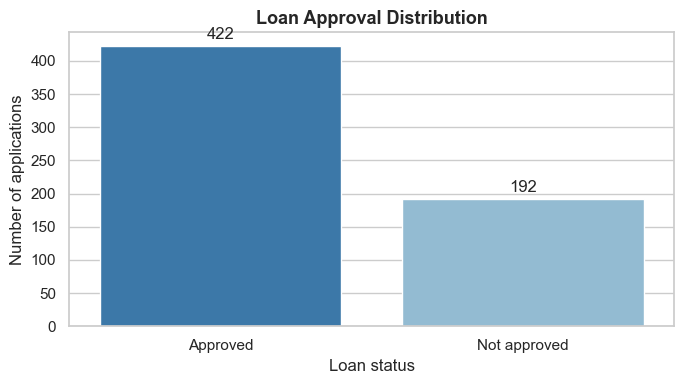

In [18]:
loan_status_summary = (
    df["Loan_Status"]
    .value_counts(dropna=False)
    .rename_axis("Loan_Status")
    .reset_index(name="application_count")
)
loan_status_summary["approval_rate"] = loan_status_summary["application_count"] / len(df) * 100
loan_status_summary["status_label"] = loan_status_summary["Loan_Status"].map({"Y": "Approved", "N": "Not approved"})

figure, axis = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=loan_status_summary, x="status_label", y="application_count",
    hue="status_label", dodge=False, legend=False,
    palette=[approved_color, rejected_color], ax=axis
)
axis.set_title("Loan Approval Distribution", fontsize=13, weight="bold")
axis.set_xlabel("Loan status")
axis.set_ylabel("Number of applications")
for container in axis.containers:
    axis.bar_label(container, fmt="%d", padding=3)
plt.tight_layout()
plt.show()


In [19]:
def show_lean_insight(observation, business_implication):
    display(Markdown(
        f"**Observation.** {observation}\n\n"
        f"**Business Implication.** {business_implication}"
    ))

overall_approval_rate = df["Loan_Status"].eq("Y").mean() * 100

show_lean_insight(
    observation=(
        f"Các hồ sơ được phê duyệt chiếm khoảng {overall_approval_rate:.0f}% tổng số dữ liệu, "
        f"so với {100 - overall_approval_rate:.0f}% hồ sơ không được phê duyệt."
    ),
    business_implication=(
        "Tập dữ liệu có mức độ mất cân bằng nhẹ nhưng chưa nghiêm trọng. Do đó, khi đánh giá mô hình ở các bước tiếp theo, cần kết hợp các chỉ số như Precision, Recall và F1-score bên cạnh Accuracy để đảm bảo đánh giá toàn diện hơn, thay vì chỉ dựa vào Accuracy."
    )
)


**Observation.** Các hồ sơ được phê duyệt chiếm khoảng 69% tổng số dữ liệu, so với 31% hồ sơ không được phê duyệt.

**Business Implication.** Tập dữ liệu có mức độ mất cân bằng nhẹ nhưng chưa nghiêm trọng. Do đó, khi đánh giá mô hình ở các bước tiếp theo, cần kết hợp các chỉ số như Precision, Recall và F1-score bên cạnh Accuracy để đảm bảo đánh giá toàn diện hơn, thay vì chỉ dựa vào Accuracy.

## 4.2 Numerical Variables

### Business Question
Các biến số chính được phân bổ như thế nào và có xuất hiện dấu hiệu lệch phân phối (skew) hoặc giá trị ngoại lai (outliers) hay không?

`Loan_Amount_Term` được loại khỏi phần phân tích này vì gần như toàn bộ dữ liệu tập trung tại một giá trị duy nhất (360 tháng) và sẽ được xử lý trực tiếp bằng giá trị trung vị trong Mục 5. `Total_Income` cũng không được đưa vào phân tích do đây là biến được tạo thêm trong giai đoạn Feature Engineering, không phải biến gốc trong dữ liệu.

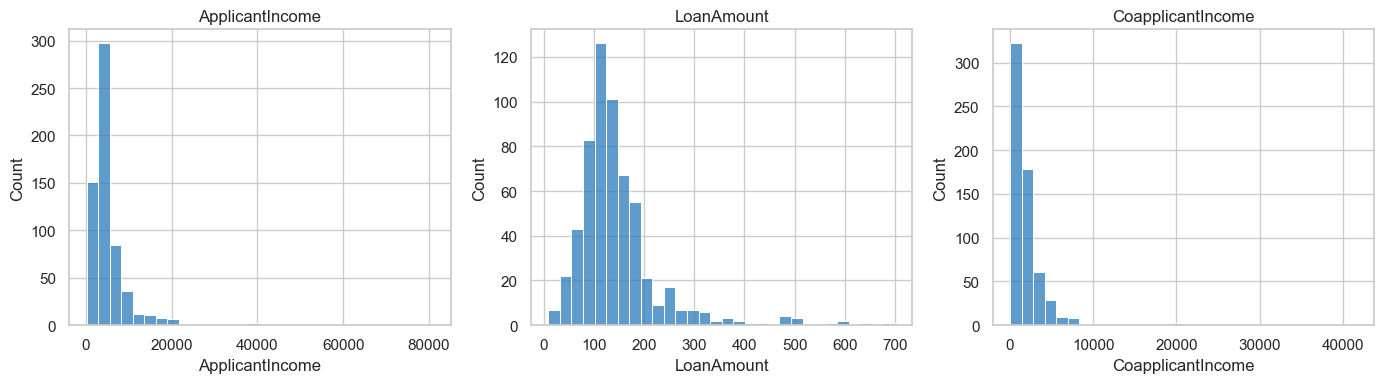

In [20]:
numeric_eda_columns = ["ApplicantIncome", "LoanAmount", "CoapplicantIncome"]

figure, axes = plt.subplots(1, 3, figsize=(14, 4))
for axis, column in zip(axes, numeric_eda_columns):
    sns.histplot(df[column].dropna(), bins=30, color=chart_palette[4], ax=axis)
    axis.set_title(column)
plt.tight_layout()
plt.show()


In [21]:
show_lean_insight(
    observation=(
        "ApplicantIncome and LoanAmount đều có phân phối lệch phải, với một số ít giá trị cao bất thường; "
        "có xu hướng tập trung lớn tại giá trị 0, phản ánh các hồ sơ không có người đồng vay."
    ),
    business_implication=(
        "Độ lệch phân phối và các giá trị ngoại lai trong `ApplicantIncome` và `LoanAmount` cần được xử lý trong giai đoạn Feature Engineering (Mục 5), có thể thông qua biến đổi log hoặc các phương pháp chuẩn hóa phù hợp. Đối với `CoapplicantIncome`, nhóm giá trị 0 mang thông tin hữu ích về đặc điểm hồ sơ vay và không nên được loại bỏ như dữ liệu nhiễu."
    )
)


**Observation.** ApplicantIncome and LoanAmount đều có phân phối lệch phải, với một số ít giá trị cao bất thường; có xu hướng tập trung lớn tại giá trị 0, phản ánh các hồ sơ không có người đồng vay.

**Business Implication.** Độ lệch phân phối và các giá trị ngoại lai trong `ApplicantIncome` và `LoanAmount` cần được xử lý trong giai đoạn Feature Engineering (Mục 5), có thể thông qua biến đổi log hoặc các phương pháp chuẩn hóa phù hợp. Đối với `CoapplicantIncome`, nhóm giá trị 0 mang thông tin hữu ích về đặc điểm hồ sơ vay và không nên được loại bỏ như dữ liệu nhiễu.

## 4.3 Categorical Variables

### Business Question
Các biến phân loại về đặc điểm người vay và hồ sơ khoản vay được phân bổ như thế nào?

Các biến được chia thành hai nhóm: Thông tin nhân khẩu học **Demographic** (Gender, Married, Education) và Đặc điểm khoản vay **Loan Profile** (Property_Area, Credit_History, Dependents). 

Phần này chỉ trình bày phân bổ dữ liệu gốc; mối quan hệ giữa các biến này với `Loan_Status` sẽ được phân tích riêng tại Mục 4.4.


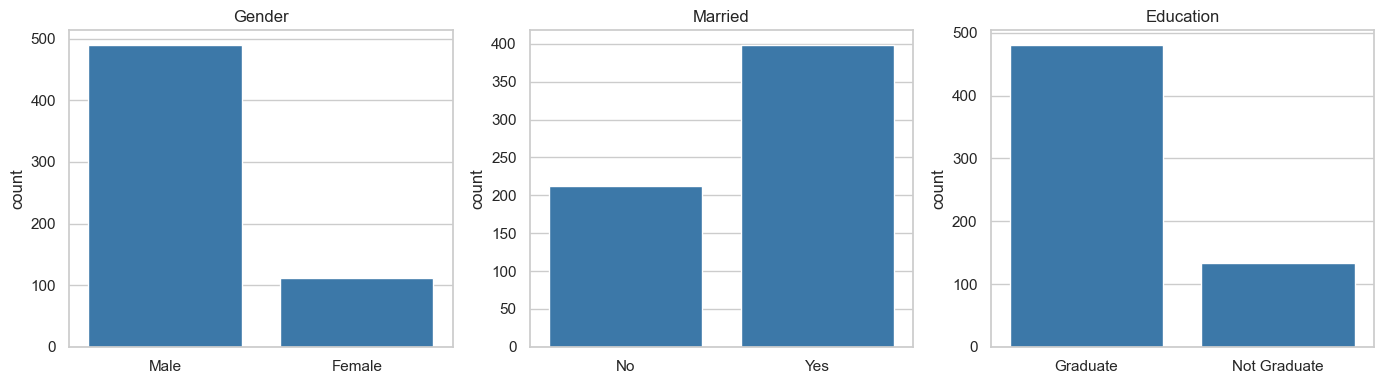

In [22]:
demographic_columns = ["Gender", "Married", "Education"]

figure, axes = plt.subplots(1, 3, figsize=(14, 4))
for axis, column in zip(axes, demographic_columns):
    sns.countplot(data=df, x=column, color=chart_palette[4], ax=axis)
    axis.set_title(column)
    axis.set_xlabel("")
plt.tight_layout()
plt.show()


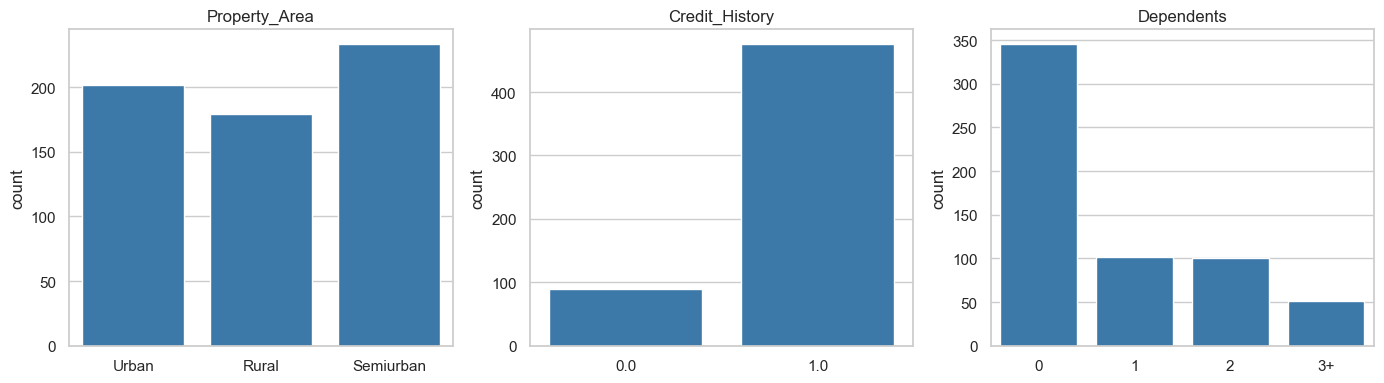

In [23]:
loan_profile_columns = ["Property_Area", "Credit_History", "Dependents"]

figure, axes = plt.subplots(1, 3, figsize=(14, 4))
for axis, column in zip(axes, loan_profile_columns):
    sns.countplot(data=df, x=column, color=chart_palette[4], ax=axis)
    axis.set_title(column)
    axis.set_xlabel("")
plt.tight_layout()
plt.show()


In [24]:
show_lean_insight(
    observation=(
        "Phần lớn người vay là nam giới, đã kết hôn và có trình độ tốt nghiệp đại học. Các hồ sơ vay chủ yếu đến từ khu vực Semiurban và Urban; đa số ứng viên có `Credit_History` đạt yêu cầu và không có người phụ thuộc. "
    ),
    business_implication=(
        "Một số nhóm khách hàng (ví dụ: chưa tốt nghiệp, khu vực Rural, có từ 3 người phụ thuộc trở lên) chiếm tỷ trọng nhỏ trong dữ liệu. Do đó, khi đánh giá mô hình cần đảm bảo mô hình hoạt động ổn định trên các nhóm khách hàng nhỏ này, thay vì chỉ tập trung vào kết quả trung bình trên toàn bộ dữ liệu."
    )
)


**Observation.** Phần lớn người vay là nam giới, đã kết hôn và có trình độ tốt nghiệp đại học. Các hồ sơ vay chủ yếu đến từ khu vực Semiurban và Urban; đa số ứng viên có `Credit_History` đạt yêu cầu và không có người phụ thuộc. 

**Business Implication.** Một số nhóm khách hàng (ví dụ: chưa tốt nghiệp, khu vực Rural, có từ 3 người phụ thuộc trở lên) chiếm tỷ trọng nhỏ trong dữ liệu. Do đó, khi đánh giá mô hình cần đảm bảo mô hình hoạt động ổn định trên các nhóm khách hàng nhỏ này, thay vì chỉ tập trung vào kết quả trung bình trên toàn bộ dữ liệu.

## 4.4 Relationship with Loan_Status

### Business Question
Những biến nào thể hiện mối quan hệ rõ ràng nhất với quyết định phê duyệt khoản vay?

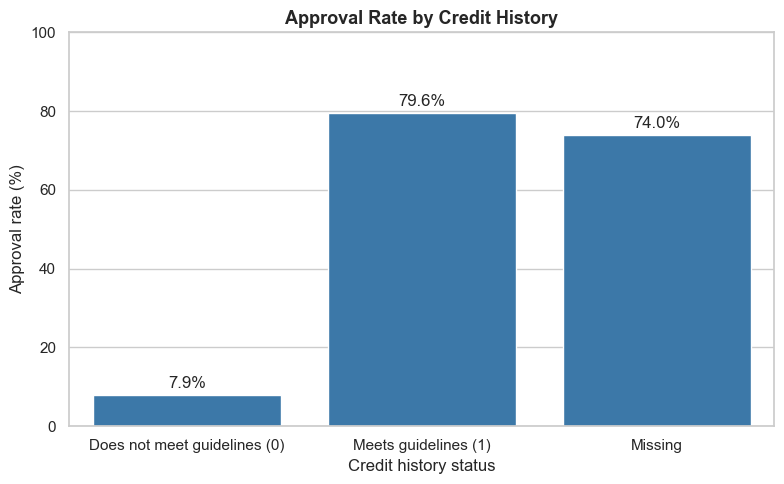

In [25]:
credit_approval_rate = calculate_approval_rate(df, "Credit_History")
credit_approval_rate["credit_history_label"] = credit_approval_rate["Credit_History"].replace({
    1.0: "Meets guidelines (1)", 0.0: "Does not meet guidelines (0)", "Missing": "Missing"
})

plot_approval_rate(
    approval_rate=credit_approval_rate.rename(columns={"credit_history_label": "Credit_History_label"}),
    group_column="Credit_History_label",
    title="Approval Rate by Credit History",
    xlabel="Credit history status"
)


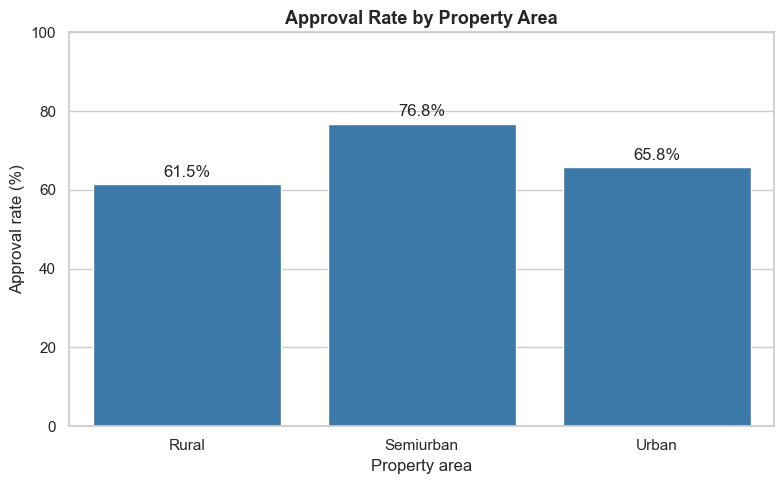

In [26]:
property_approval_rate = calculate_approval_rate(df, "Property_Area")

plot_approval_rate(
    approval_rate=property_approval_rate,
    group_column="Property_Area",
    title="Approval Rate by Property Area",
    xlabel="Property area"
)


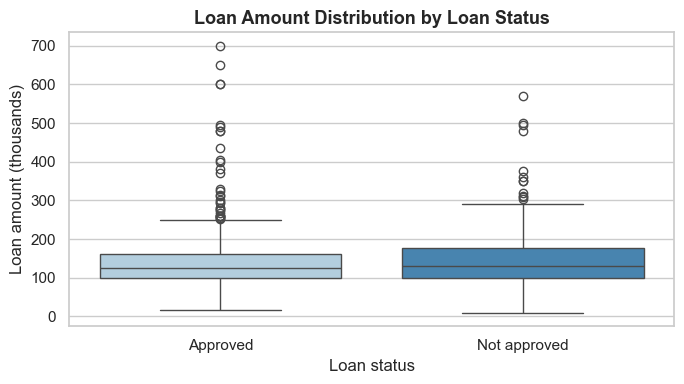

In [27]:
financial_plot_df = df[["LoanAmount", "Loan_Status"]].copy()
financial_plot_df["status_label"] = financial_plot_df["Loan_Status"].map({"Y": "Approved", "N": "Not approved"})

figure, axis = plt.subplots(figsize=(7, 4))
sns.boxplot(
    data=financial_plot_df, x="status_label", y="LoanAmount",
    hue="status_label", dodge=False, legend=False, palette="Blues", ax=axis
)
axis.set_title("Loan Amount Distribution by Loan Status", fontsize=13, weight="bold")
axis.set_xlabel("Loan status")
axis.set_ylabel("Loan amount (thousands)")
plt.tight_layout()
plt.show()


In [28]:
credit_meets_rate = credit_approval_rate.loc[credit_approval_rate["Credit_History"] == 1.0, "approval_rate"].iloc[0]
credit_not_meets_rate = credit_approval_rate.loc[credit_approval_rate["Credit_History"] == 0.0, "approval_rate"].iloc[0]
highest_property_row = property_approval_rate.loc[property_approval_rate["approval_rate"].idxmax()]

show_lean_insight(
    observation=(
        f"Credit_History thể hiện sự khác biệt rõ rệt nhất về tỷ lệ phê duyệt khoản vay ({credit_meets_rate:.0f}% vs. "
        f"{credit_not_meets_rate:.0f}%); có mức độ khác biệt thấp hơn, trong đó nhóm {highest_property_row['Property_Area']} "
        "có tỷ lệ được phê duyệt cao nhất. Phân phối `LoanAmount` giữa nhóm được phê duyệt và không được phê duyệt có sự chồng lấn đáng kể."
    ),
    business_implication=(
        "Credit_History nên được xem là biến sàng lọc quan trọng trong quá trình đánh giá hồ sơ vay. Property_Area chỉ là tín hiệu bổ sung với mức ảnh hưởng thấp hơn. LoanAmount đơn lẻ không đủ khả năng phân biệt kết quả phê duyệt, do đó nên được kết hợp với thông tin thu nhập để tạo ra biến phản ánh khả năng chi trả (affordability feature) trong giai đoạn Feature Engineering."
    )
)


**Observation.** Credit_History thể hiện sự khác biệt rõ rệt nhất về tỷ lệ phê duyệt khoản vay (80% vs. 8%); có mức độ khác biệt thấp hơn, trong đó nhóm Semiurban có tỷ lệ được phê duyệt cao nhất. Phân phối `LoanAmount` giữa nhóm được phê duyệt và không được phê duyệt có sự chồng lấn đáng kể.

**Business Implication.** Credit_History nên được xem là biến sàng lọc quan trọng trong quá trình đánh giá hồ sơ vay. Property_Area chỉ là tín hiệu bổ sung với mức ảnh hưởng thấp hơn. LoanAmount đơn lẻ không đủ khả năng phân biệt kết quả phê duyệt, do đó nên được kết hợp với thông tin thu nhập để tạo ra biến phản ánh khả năng chi trả (affordability feature) trong giai đoạn Feature Engineering.

## 4.5 Correlation Analysis

### Business Question

"Các biến `ApplicantIncome`, `LoanAmount`, `Credit_History` và `Loan_Status` có mối quan hệ với nhau như thế nào?"


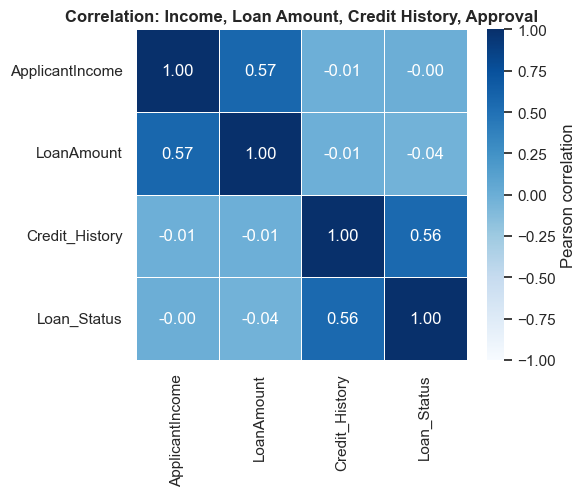

In [29]:
correlation_df = df[["ApplicantIncome", "LoanAmount", "Credit_History"]].copy()
correlation_df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})
focused_correlation = correlation_df.corr()

figure, axis = plt.subplots(figsize=(6, 5))
sns.heatmap(
    focused_correlation, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1,
    square=True, linewidths=0.5, cbar_kws={"label": "Pearson correlation"}, ax=axis
)
axis.set_title("Correlation: Income, Loan Amount, Credit History, Approval", fontsize=12, weight="bold")
plt.tight_layout()
plt.show()


In [30]:
show_lean_insight(
    observation=(
        f"ApplicantIncome and LoanAmount có mối tương quan dương ở mức trung bình "
        f"({focused_correlation.loc['ApplicantIncome', 'LoanAmount']:.2f}); Credit_History có mức tương quan lớn nhất vượt trội với "
        f" Loan_Status ({focused_correlation.loc['Credit_History', 'Loan_Status']:.2f}), "
        
    ),
    business_implication=(
        "Credit_History thể hiện tín hiệu liên quan đến khả năng được phê duyệt khoản vay mạnh hơn so với các biến tài chính gốc. Vì vậy, đây nên là biến ưu tiên được giữ lại trong giai đoạn Feature Engineering và xây dựng mô hình."
    )
)


**Observation.** ApplicantIncome and LoanAmount có mối tương quan dương ở mức trung bình (0.57); Credit_History có mức tương quan lớn nhất vượt trội với  Loan_Status (0.56), 

**Business Implication.** Credit_History thể hiện tín hiệu liên quan đến khả năng được phê duyệt khoản vay mạnh hơn so với các biến tài chính gốc. Vì vậy, đây nên là biến ưu tiên được giữ lại trong giai đoạn Feature Engineering và xây dựng mô hình.

### Section 4 Summary

- Biến mục tiêu có mức độ mất cân bằng nhẹ (~69% hồ sơ được phê duyệt). Do đó, các mô hình sau này cần được đánh giá bằng Precision, Recall và F1-score, không chỉ dựa trên Accuracy.
`Credit_History` là biến nổi bật nhất cần được giữ lại trong giai đoạn Feature Engineering và xây dựng mô hình.
- `ApplicantIncome` và `LoanAmount` có phân phối lệch và xuất hiện giá trị ngoại lai, cần được xử lý bằng các phương pháp biến đổi phù hợp. Hai biến này khi sử dụng riêng lẻ không đủ khả năng phân biệt kết quả phê duyệt, do đó nên phát triển thêm biến phản ánh khả năng chi trả dựa trên mối quan hệ giữa thu nhập và khoản vay.
- Các phát hiện trên chỉ phản ánh mối liên hệ trong dữ liệu lịch sử, không phải quan hệ nhân quả hay quy tắc phê duyệt cuối cùng.


# 5. Feature Engineering

## 5.1 Cleaning Strategy
### Business Question

Làm thế nào để xử lý dữ liệu thiếu nhằm duy trì chất lượng dữ liệu và đảm bảo quy trình học máy công bằng, không gây sai lệch?

Để tránh hiện tượng rò rỉ dữ liệu (data leakage), các tham số dùng cho việc điền khuyết chỉ được tính toán dựa trên **tập huấn luyện (Training set)** sau khi thực hiện chia Train/Test. Các bộ xử lý dữ liệu (imputer) sau khi được huấn luyện sẽ được áp dụng nhất quán cho cả tập Training và Test.

Cách tiếp cận này đảm bảo không có thông tin từ tập Test được sử dụng trong quá trình huấn luyện mô hình, giúp kết quả đánh giá phản ánh chính xác hơn khả năng dự báo trên dữ liệu mới.


| Variable | Imputation Strategy | Applied During |
|---|---|---|
| Credit_History | Mode + Missing flag | Train only |
| Gender, Married, Dependents, Self_Employed | Mode | Train only |
| LoanAmount, Loan_Amount_Term | Median | Train only |


## 5.2 Missing Value Treatment
### Business Question 
"Cần xử lý dữ liệu thiếu như thế nào để bảo toàn thông tin kinh doanh trước khi tạo biến mới (Feature Creation)?"

### 5.3.1 Handling Missing Credit History

In [31]:
df["Credit_History_Missing"] = df["Credit_History"].isna().astype(int)

credit_missing_approval = (
    df.groupby("Credit_History_Missing")["Loan_Status"]
    .apply(lambda s: (s == "Y").mean() * 100)
    .rename("approval_rate_pct")
    .reset_index()
)
credit_missing_approval


,Credit_History_Missing,approval_rate_pct
0,0,68.26
1,1,74.00


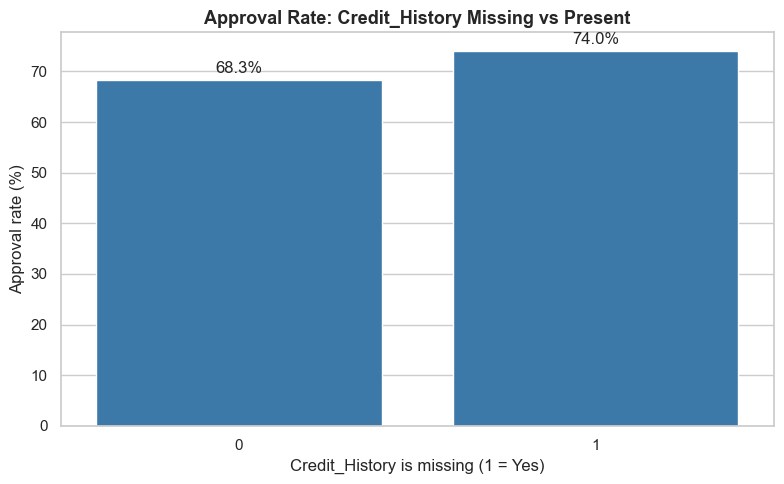

In [32]:
figure, axis = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=credit_missing_approval,
    x="Credit_History_Missing",
    y="approval_rate_pct",
    color=chart_palette[4],
    ax=axis
)
axis.set_title("Approval Rate: Credit_History Missing vs Present", fontsize=13, weight="bold")
axis.set_xlabel("Credit_History is missing (1 = Yes)")
axis.set_ylabel("Approval rate (%)")
for container in axis.containers:
    axis.bar_label(container, fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()


In [33]:
missing_rate = credit_missing_approval.loc[credit_missing_approval.Credit_History_Missing == 1, "approval_rate_pct"].iloc[0]
present_rate = credit_missing_approval.loc[credit_missing_approval.Credit_History_Missing == 0, "approval_rate_pct"].iloc[0]

show_insight(
    observation=f"Các ứng viên bị thiếu thông tin `Credit_History` có tỉ lệ phê duyệt là {missing_rate:.1f}% , so với {present_rate:.1f}% nhóm ứng viên có đủ dữ liệu trong quá khứ.",
    interpretation="Việc thiếu dữ liệu trong `Credit_History` không phải là nhiễu ngẫu nhiên; nhóm này có kết quả phê duyệt khác biệt so với nhóm có thông tin đầy đủ. Vì vậy, việc gộp toàn bộ giá trị thiếu vào một giá trị điền khuyết duy nhất có thể làm mất đi thông tin quan trọng trong dữ liệu.",
    business_implication="Company X nên duy trì một biến đánh dấu trạng thái thiếu `Credit_History` trong quá trình xây dựng mô hình. Hồ sơ có lịch sử tín dụng chưa xác định nên được xem là một nhóm rủi ro riêng trong quy trình sàng lọc, thay vì được xem tương đương với khách hàng có lịch sử tín dụng tốt hoặc xấu đã được xác nhận."
)


**Observation.** Các ứng viên bị thiếu thông tin `Credit_History` có tỉ lệ phê duyệt là 74.0% , so với 68.3% nhóm ứng viên có đủ dữ liệu trong quá khứ.

**Interpretation.** Việc thiếu dữ liệu trong `Credit_History` không phải là nhiễu ngẫu nhiên; nhóm này có kết quả phê duyệt khác biệt so với nhóm có thông tin đầy đủ. Vì vậy, việc gộp toàn bộ giá trị thiếu vào một giá trị điền khuyết duy nhất có thể làm mất đi thông tin quan trọng trong dữ liệu.

**Business Implication.** Company X nên duy trì một biến đánh dấu trạng thái thiếu `Credit_History` trong quá trình xây dựng mô hình. Hồ sơ có lịch sử tín dụng chưa xác định nên được xem là một nhóm rủi ro riêng trong quy trình sàng lọc, thay vì được xem tương đương với khách hàng có lịch sử tín dụng tốt hoặc xấu đã được xác nhận.

### 5.3.2 Handling Missing Categorical Values

In [34]:
categorical_to_impute = ["Gender", "Married", "Dependents", "Self_Employed"]
descriptive_mode_log = []
for column in categorical_to_impute:
    mode_value = df[column].mode().iloc[0]
    missing_count = int(df[column].isna().sum())
    descriptive_mode_log.append({
        "column": column,
        "missing_count": missing_count,
        "full_data_mode_preview": mode_value,
    })

pd.DataFrame(descriptive_mode_log)

,column,missing_count,full_data_mode_preview
0,Gender,13,Male
1,Married,3,Yes
2,Dependents,15,0
3,Self_Employed,32,No


#### Interpretation
Các biến phân loại bị thiếu dữ liệu chỉ chiếm một tỷ lệ nhỏ trong tổng số quan sát.

Phương pháp điền khuyết bằng giá trị xuất hiện nhiều nhất (Mode Imputation) được áp dụng vì các biến này đại diện cho nhóm phân loại rời rạc. Cách xử lý này giúp duy trì phân phối dữ liệu ban đầu mà không tạo ra các giá trị không thực tế.

#### Business Implication

Việc hoàn thiện các giá trị thiếu trong biến phân loại giúp duy trì đầy đủ các hồ sơ vay cho quá trình phân tích, đồng thời đảm bảo tính nhất quán của thông tin phân loại khi đưa vào các mô hình học máy tiếp theo.

### 5.3.3 Handling Missing Numerical Values

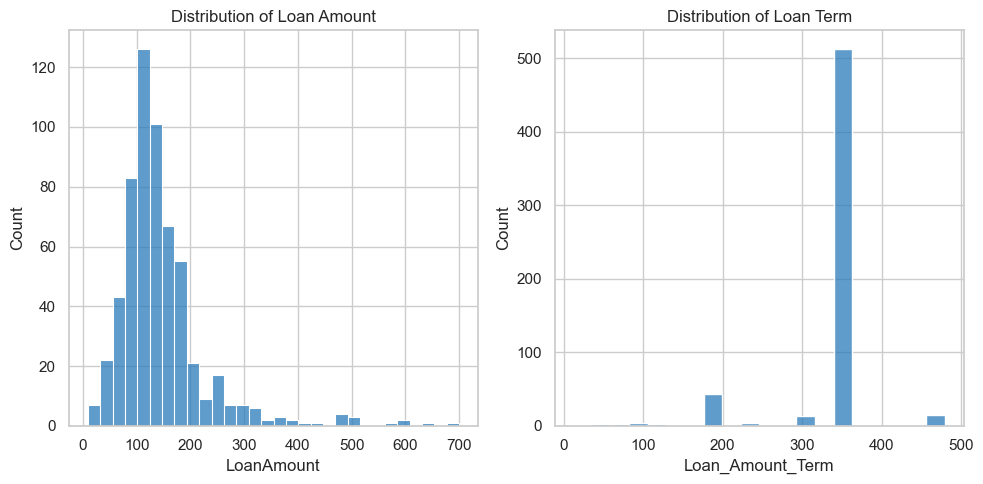

In [35]:
figure, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(df["LoanAmount"].dropna(), bins=30, color=chart_palette[4], ax=axes[0])
axes[0].set_title("Distribution of Loan Amount")
sns.histplot(df["Loan_Amount_Term"].dropna(), bins=20, color=chart_palette[4], ax=axes[1])
axes[1].set_title("Distribution of Loan Term")
plt.tight_layout()
plt.show()


In [36]:
numeric_to_impute = ["LoanAmount", "Loan_Amount_Term"]
descriptive_median_log = []
for column in numeric_to_impute:
    median_value = df[column].median()
    missing_count = int(df[column].isna().sum())
    descriptive_median_log.append({
        "column": column,
        "missing_count": missing_count,
        "median_reference": median_value,
    })

pd.DataFrame(descriptive_median_log)


,column,missing_count,median_reference
0,LoanAmount,22,128.00
1,Loan_Amount_Term,14,360.00


In [37]:
show_insight( 
    observation="`LoanAmount` có phân phối lệch phải và `Loan_Amount_Term` tập trung chủ yếu tại 360 tháng, khiến giá trị trung bình bị ảnh hưởng bởi một số ít giá trị cao hoặc không phổ biến.", 
    interpretation="Phương pháp điền khuyết bằng giá trị trung vị (Median Imputation) được áp dụng vì trung vị có khả năng chống chịu tốt hơn với phân phối lệch và giá trị ngoại lai so với giá trị trung bình. Điều này giúp tạo ra giá trị thay thế phù hợp hơn cho các trường dữ liệu số bị thiếu.", 
    business_implication="Việc sử dụng trung vị được tính từ tập Train giúp tránh làm sai lệch đánh giá về khả năng chi trả khoản vay của nhóm khách hàng phổ biến, đồng thời đảm bảo tập Test vẫn hoàn toàn độc lập trong quá trình huấn luyện mô hình." )

**Observation.** `LoanAmount` có phân phối lệch phải và `Loan_Amount_Term` tập trung chủ yếu tại 360 tháng, khiến giá trị trung bình bị ảnh hưởng bởi một số ít giá trị cao hoặc không phổ biến.

**Interpretation.** Phương pháp điền khuyết bằng giá trị trung vị (Median Imputation) được áp dụng vì trung vị có khả năng chống chịu tốt hơn với phân phối lệch và giá trị ngoại lai so với giá trị trung bình. Điều này giúp tạo ra giá trị thay thế phù hợp hơn cho các trường dữ liệu số bị thiếu.

**Business Implication.** Việc sử dụng trung vị được tính từ tập Train giúp tránh làm sai lệch đánh giá về khả năng chi trả khoản vay của nhóm khách hàng phổ biến, đồng thời đảm bảo tập Test vẫn hoàn toàn độc lập trong quá trình huấn luyện mô hình.

## 5.4 Distribution Transformation

### Business Question

Các biến tài chính có phân phối lệch cần được biến đổi như thế nào để cải thiện độ ổn định của mô hình mà vẫn bảo toàn ý nghĩa kinh doanh?


In [38]:
skew_before = df[["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]].skew()
skew_before


ApplicantIncome     6.54
CoapplicantIncome   7.49
LoanAmount          2.68
dtype: float64

#### Interpretation

`ApplicantIncome`, `CoapplicantIncome` và `LoanAmount` có phân phối lệch phải, cho thấy một số ít ứng viên có giá trị tài chính cao hơn đáng kể so với phần lớn dữ liệu.

Để giảm ảnh hưởng của các giá trị cực đoan mà không loại bỏ các quan sát hợp lệ, phương pháp biến đổi log (Log Transformation) được áp dụng cho các biến có độ lệch cao.

In [39]:
df["ApplicantIncome_Log"] = np.log1p(df["ApplicantIncome"])
df["CoapplicantIncome_Log"] = np.log1p(df["CoapplicantIncome"])
df["LoanAmount_Log"] = np.log1p(df["LoanAmount"])

In [40]:
# Compare skewness before and after log transformation
skew_before = df[
    ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]
].skew()

skew_after = df[
    ["ApplicantIncome_Log", "CoapplicantIncome_Log", "LoanAmount_Log"]
].skew()

skew_comparison = pd.DataFrame({
    "Before": skew_before.values,
    "After": skew_after.values
}, index=["ApplicantIncome", "CoapplicantIncome", "LoanAmount"])

skew_comparison

,Before,After
ApplicantIncome,6.54,0.48
CoapplicantIncome,7.49,-0.17
LoanAmount,2.68,-0.15


#### Interpretation

Biến đổi log giúp giảm đáng kể độ lệch phải của các biến tài chính, tạo ra phân phối cân bằng hơn. Điều này hỗ trợ mô hình học máy học được các xu hướng ổn định hơn, đồng thời vẫn duy trì đầy đủ các hồ sơ vay hợp lệ trong dữ liệu.

#### Business Implication

Thay vì loại bỏ các hồ sơ vay có giá trị tài chính cao, biến đổi log giúp giữ lại thông tin kinh doanh quan trọng trong dữ liệu và giảm ảnh hưởng của các quan sát cực đoan. Cách xử lý này nâng cao chất lượng dữ liệu phục vụ huấn luyện mô hình mà không loại bỏ các khách hàng có khả năng vay hợp lệ.

## 5.5 Feature Engineering (New Feature Creation)

### Business Question

Làm thế nào để xây dựng các biến mới nhằm phản ánh tốt hơn năng lực tài chính của khách hàng và cải thiện hiệu quả dự báo của các mô hình học máy?

### Section Overview

Các biến gốc như `ApplicantIncome` và `LoanAmount` cung cấp thông tin hữu ích khi được xem xét riêng lẻ. Tuy nhiên, các biến này chưa phản ánh đầy đủ khả năng trả nợ hoặc mức độ gánh nặng khoản vay của người vay.

Dựa trên các phát hiện từ quá trình Phân tích dữ liệu khám phá (EDA), một số biến hướng đến góc nhìn kinh doanh được xây dựng nhằm thể hiện rõ hơn tổng thu nhập hộ gia đình, khả năng chi trả và năng lực hoàn trả khoản vay của khách hàng.


In [41]:
df["Total_Income"] = df["ApplicantIncome"] + df["CoapplicantIncome"]

df["Total_Income"] = df["ApplicantIncome"] + df["CoapplicantIncome"]

# Log-transformed income features
df["CoapplicantIncome_log"] = np.log1p(df["CoapplicantIncome"])
df["Total_Income_log"] = np.log1p(df["Total_Income"])

df["Total_Income_log"] = np.log1p(df["Total_Income"])

def engineer_dependent_features(frame):
    """Create features that depend on LoanAmount and Loan_Amount_Term.

    This function is applied separately to the Train and Test datasets
    after missing-value imputation to ensure a leak-safe workflow.
    """
    frame = frame.copy()
    # Estimated Monthly Installment (EMI)
    # LoanAmount is recorded in thousands; multiply by 1,000 before calculation.
    frame["EMI"] = (frame["LoanAmount"] * 1000) / frame["Loan_Amount_Term"]
    # Loan affordability relative to total household income.
    frame["Loan_to_Income_Ratio"] = (frame["LoanAmount"] * 1000) / frame["Total_Income"]
    return frame

### Feature engineering summary table

| Feature | Purpose |
|---|---|
| `Total_Income` | Household earning capacity |
| `Total_Income_log` | Reduce skewness |
| `LoanAmount_log` | Stabilize distribution |
| `EMI` | Monthly repayment burden |
| `Loan_to_Income_Ratio` | Loan affordabilitye |


### Business Implication

Các biến được xây dựng trong giai đoạn Feature Engineering giúp chuyển đổi thông tin thô của khách hàng thành các chỉ số có ý nghĩa kinh doanh, như năng lực thu nhập của hộ gia đình, mức độ gánh nặng trả nợ và khả năng chi trả khoản vay. Những biến này phản ánh tốt hơn các yếu tố tài chính thường được xem xét trong quá trình đánh giá hồ sơ vay, đồng thời cung cấp đầu vào có giá trị hơn cho các mô hình dự báo được phát triển ở phần tiếp theo.

# 6. Data Preprocessing

## Section Overview
Phần này chuẩn bị dữ liệu cho quá trình xây dựng mô hình học máy thông qua việc mã hóa các biến phân loại, hoàn thiện xử lý dữ liệu thiếu sau khi chia tập Train/Test và thực hiện chuẩn hóa biến khi cần thiết.

Quy trình tiền xử lý được thiết kế nhằm đảm bảo mọi phép biến đổi được học từ tập Training trước khi áp dụng cho tập Test, giúp ngăn ngừa hiện tượng rò rỉ dữ liệu (data leakage) và đảm bảo tính khách quan trong quá trình đánh giá mô hình.


## 6.1 Categorical Encoding
### Business Question
Các biến phân loại nên được chuyển đổi sang dạng số như thế nào để phù hợp với các mô hình học máy?


In [42]:
# Safe categorical encoding before Train/Test split
binary_maps_safe = {
    "Education": {"Graduate": 1, "Not Graduate": 0},
    "Loan_Status": {"Y": 1, "N": 0},
}

for column, mapping in binary_maps_safe.items():
    df[column] = df[column].map(mapping)

df[list(binary_maps_safe.keys())].head()


,Education,Loan_Status
0,1,1
1,1,0
2,1,1
3,0,1
4,1,1


In [43]:
df = pd.get_dummies(df, columns=["Property_Area"], prefix="Property_Area")

property_area_columns = [c for c in df.columns if c.startswith("Property_Area_")]
df[property_area_columns] = df[property_area_columns].astype(int)

df[property_area_columns].sum()


Property_Area_Rural        179
Property_Area_Semiurban    233
Property_Area_Urban        202
dtype: int64

In [44]:
show_insight(
    observation="`Education` và `Loan_Status` được mã hóa nhãn (Label Encoding), trong khi Property_Area được mã hóa One-Hot Encoding thành ba biến nhị phân tương ứng.",
    interpretation="Các biến nhị phân phù hợp với phương pháp Label Encoding để biểu diễn dữ liệu hiệu quả. Trong khi đó, One-Hot Encoding được áp dụng cho `Property_Area` nhằm tránh tạo ra mối quan hệ thứ tự giả giữa các nhóm khu vực.",
    business_implication="Việc mã hóa biến phân loại phù hợp giúp mô hình học máy khai thác được thông tin từ đặc điểm khách hàng, đồng thời duy trì đúng ý nghĩa ban đầu của từng nhóm dữ liệu trong bối cảnh đánh giá hồ sơ vay."
)

**Observation.** `Education` và `Loan_Status` được mã hóa nhãn (Label Encoding), trong khi Property_Area được mã hóa One-Hot Encoding thành ba biến nhị phân tương ứng.

**Interpretation.** Các biến nhị phân phù hợp với phương pháp Label Encoding để biểu diễn dữ liệu hiệu quả. Trong khi đó, One-Hot Encoding được áp dụng cho `Property_Area` nhằm tránh tạo ra mối quan hệ thứ tự giả giữa các nhóm khu vực.

**Business Implication.** Việc mã hóa biến phân loại phù hợp giúp mô hình học máy khai thác được thông tin từ đặc điểm khách hàng, đồng thời duy trì đúng ý nghĩa ban đầu của từng nhóm dữ liệu trong bối cảnh đánh giá hồ sơ vay.

## 6.2 Final Assembly

### Business Question
Những biến nào cần được giữ lại trong tập dữ liệu đã sẵn sàng một phần cho mô hình, và những biến nào cần được loại bỏ theo phạm vi thực hiện của nhóm?

### Business Implication

Tập dữ liệu sau làm sạch giữ lại toàn bộ các biến cần thiết cho quá trình xây dựng mô hình tiếp theo, đồng thời duy trì khả năng truy vết hồ sơ thông qua Loan_ID. Các bước tiền xử lý yêu cầu thực hiện riêng trên tập Train sẽ được hoàn thiện trong giai đoạn phát triển mô hình.


In [45]:
final_column_order = (
    ["Loan_ID"] +
    ["Gender", "Married", "Dependents", "Education", "Self_Employed"] +
    property_area_columns +
    [
        "ApplicantIncome",
        "CoapplicantIncome",
        "CoapplicantIncome_log",
        "Total_Income",
        "Total_Income_log",
        "LoanAmount",
        "Loan_Amount_Term",
    ] +
    ["Credit_History", "Credit_History_Missing"] +
    ["Loan_Status"]
)

df = df[final_column_order]
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,ApplicantIncome,CoapplicantIncome,CoapplicantIncome_log,Total_Income,Total_Income_log,LoanAmount,Loan_Amount_Term,Credit_History,Credit_History_Missing,Loan_Status
0,LP001002,Male,No,0,1,No,0,0,1,5849,0.00,0.00,"5,849.00",8.67,NaN,360.00,1.00,0,1
1,LP001003,Male,Yes,1,1,No,1,0,0,4583,"1,508.00",7.32,"6,091.00",8.71,128.00,360.00,1.00,0,0
2,LP001005,Male,Yes,0,1,Yes,0,0,1,3000,0.00,0.00,"3,000.00",8.01,66.00,360.00,1.00,0,1
3,LP001006,Male,Yes,0,0,No,0,0,1,2583,"2,358.00",7.77,"4,941.00",8.51,120.00,360.00,1.00,0,1
4,LP001008,Male,No,0,1,No,0,0,1,6000,0.00,0.00,"6,000.00",8.70,141.00,360.00,1.00,0,1


In [46]:
expected_deferred_columns = {
    "Gender", "Married", "Dependents", "Self_Employed",
    "Credit_History", "LoanAmount", "Loan_Amount_Term",
}
missing_now = df.isna().sum()
missing_now = set(missing_now[missing_now > 0].index)

assert missing_now.issubset(expected_deferred_columns), (
    f"Unexpected columns have missing values: {missing_now - expected_deferred_columns}"
)
assert df["Loan_ID"].nunique() == len(df), "Loan_ID is no longer unique."
print("Data quality checks passed.")


Data quality checks passed.


In [47]:
output_path = Path("loan_cleaned.csv")
df.to_csv(output_path, index=False)


## 6.3 Data Preparation Summary

**Các bước đã hoàn thành trước khi chia Train/Test**

1. Tạo biến `Credit_History_Missing` nhằm giữ lại thông tin về trạng thái thiếu dữ liệu.
2. Áp dụng biến đổi `log1p` cho `CoapplicantIncome` và `Total_Income`.
3. Tạo các biến mới `Total_Income` và `Total_Income_log`.
4. Mã hóa các biến Education`, `Property_Area` và `Loan_Status`.
5. Xuất tập dữ liệu đã được làm sạch một phần, đồng thời giữ lại các biến yêu cầu xử lý riêng trên tập Train.

**Các bước được thực hiện tại Mục 7.3**

1. Điền khuyết chỉ dựa trên tập Train (Mode cho biến phân loại, Median cho biến số).
2. Mã hóa các biến phân loại phụ thuộc vào kết quả xử lý dữ liệu thiếu.
3. Tạo các biến mới `LoanAmount_log`, `EMI` và `Loan_to_Income_Ratio`.

**Business Implication**

Tập dữ liệu hiện đã được chuẩn bị cho quá trình phát triển mô hình theo quy trình đảm bảo không xảy ra rò rỉ dữ liệu (leak-safe workflow). Các bước tiền xử lý cần sử dụng tham số học từ dữ liệu sẽ được trì hoãn đến sau khi chia Train/Test, giúp đảm bảo việc đánh giá hiệu quả mô hình khách quan và không bị sai lệch.

# 7. Model Development

## 7.1 Train/Test Split Strategy

Để đảm bảo đánh giá mô hình khách quan, tất cả các bước tiền xử lý cần sử dụng tham số được học từ dữ liệu (ví dụ: xử lý dữ liệu thiếu) được thực hiện sau khi chia tập Train/Test.

Các bộ xử lý dữ liệu thiếu (imputer) chỉ được huấn luyện dựa trên tập Training và sau đó áp dụng cho tập Test. Các phép biến đổi xác định (ví dụ: công thức tạo biến và biến đổi log) cũng được thực hiện theo cùng quy trình, đảm bảo không có thông tin từ tập Test ảnh hưởng đến quá trình huấn luyện mô hình.

Thiết kế quy trình không rò rỉ dữ liệu (leak-safe workflow) này giúp cung cấp ước lượng khách quan về hiệu quả mô hình và tuân thủ các thực hành chuẩn trong học máy.

In [48]:
# Standard Library

# Third-party Library
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, make_scorer,
                              confusion_matrix, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', None)


In [49]:
# Load the cleaned dataset prepared for model development
df = pd.read_csv("loan_cleaned.csv")

print(df.shape)
df.head()

(614, 19)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,ApplicantIncome,CoapplicantIncome,CoapplicantIncome_log,Total_Income,Total_Income_log,LoanAmount,Loan_Amount_Term,Credit_History,Credit_History_Missing,Loan_Status
0,LP001002,Male,No,0,1,No,0,0,1,5849,0.00,0.00,"5,849.00",8.67,NaN,360.00,1.00,0,1
1,LP001003,Male,Yes,1,1,No,1,0,0,4583,"1,508.00",7.32,"6,091.00",8.71,128.00,360.00,1.00,0,0
2,LP001005,Male,Yes,0,1,Yes,0,0,1,3000,0.00,0.00,"3,000.00",8.01,66.00,360.00,1.00,0,1
3,LP001006,Male,Yes,0,0,No,0,0,1,2583,"2,358.00",7.77,"4,941.00",8.51,120.00,360.00,1.00,0,1
4,LP001008,Male,No,0,1,No,0,0,1,6000,0.00,0.00,"6,000.00",8.70,141.00,360.00,1.00,0,1


## 7.1 Removing Unnecessary Columns

Trước khi huấn luyện mô hình, hai biến được loại bỏ:

- **`Loan_ID`**: chỉ là biến định danh và không chứa thông tin có giá trị dự báo.
- **`Property_Area_Rural`**: được loại bỏ để tránh hiện tượng bẫy biến giả (dummy variable trap), trong đó Rural được sử dụng làm nhóm tham chiếu.

In [50]:
df_model = df.drop(columns=["Loan_ID", "Property_Area_Rural"])

print(
    "Columns:",
    df.shape[1],
    "→",
    df_model.shape[1]
)

df_model.head()

Columns: 19 → 17


,Gender,Married,Dependents,Education,Self_Employed,Property_Area_Semiurban,Property_Area_Urban,ApplicantIncome,CoapplicantIncome,CoapplicantIncome_log,Total_Income,Total_Income_log,LoanAmount,Loan_Amount_Term,Credit_History,Credit_History_Missing,Loan_Status
0,Male,No,0,1,No,0,1,5849,0.00,0.00,"5,849.00",8.67,NaN,360.00,1.00,0,1
1,Male,Yes,1,1,No,0,0,4583,"1,508.00",7.32,"6,091.00",8.71,128.00,360.00,1.00,0,0
2,Male,Yes,0,1,Yes,0,1,3000,0.00,0.00,"3,000.00",8.01,66.00,360.00,1.00,0,1
3,Male,Yes,0,0,No,0,1,2583,"2,358.00",7.77,"4,941.00",8.51,120.00,360.00,1.00,0,1
4,Male,No,0,1,No,0,1,6000,0.00,0.00,"6,000.00",8.70,141.00,360.00,1.00,0,1


### Business Implication

Việc loại bỏ các biến định danh và biến giả dư thừa giúp đơn giản hóa tập đặc trưng, đồng thời hạn chế hiện tượng đa cộng tuyến trong mô hình Logistic Regression mà không làm mất đi thông tin có giá trị cho dự báo.

## 7.2 Train/Test Split

### Business Question

Làm thế nào để chia dữ liệu nhằm đảm bảo đánh giá hiệu quả mô hình một cách khách quan?

Tập dữ liệu được chia thành **80% Training** và **20% Test** trước khi thực hiện các bước tiền xử lý cần sử dụng tham số được học từ dữ liệu. Điều này đảm bảo rằng các bước như xử lý dữ liệu thiếu, tạo biến mới và mã hóa biến phân loại chỉ được học từ tập Training, ngăn ngừa hiện tượng rò rỉ dữ liệu (data leakage) sang tập Test.

In [51]:
idx_trainval, idx_test_final = train_test_split(
    df_model.index,
    test_size=0.2,
    random_state=42,
    stratify=df_model["Loan_Status"]
)

train_df = df_model.loc[idx_trainval].copy()
test_df = df_model.loc[idx_test_final].copy()

print(f"Training set: {len(train_df)} rows")
print(f"Test set: {len(test_df)} rows")

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

precision_scorer = make_scorer(precision_score)

Training set: 491 rows
Test set: 123 rows


### Validation Strategy

Phương pháp **5-fold Stratified Cross-Validation** được áp dụng trong quá trình tối ưu tham số mô hình nhằm duy trì tỷ lệ phân bổ phê duyệt khoản vay ban đầu giữa các tập con.

Chỉ số **Precision** được lựa chọn làm tiêu chí tối ưu vì việc phê duyệt một khoản vay không phù hợp có thể gây tổn thất lớn hơn cho doanh nghiệp so với việc yêu cầu xem xét thủ công bổ sung.

### Business Implication

Việc tách tập Test trước khi huấn luyện mô hình đảm bảo các chỉ số đánh giá phản ánh đúng khả năng hoạt động của mô hình trên các hồ sơ vay mới trong tương lai, thay vì chỉ thể hiện hiệu quả trên dữ liệu mà mô hình đã được tiếp cận trong quá trình huấn luyện.

## 7.3 Train-only Preprocessing

### Business Question

Làm thế nào để xử lý dữ liệu thiếu mà không gây ra hiện tượng rò rỉ dữ liệu?

Tất cả các bộ xử lý dữ liệu thiếu (imputer) chỉ được huấn luyện dựa trên **tập Training** và sau đó được áp dụng cho cả **tập Training** và **tập Test**. Sau khi hoàn tất xử lý dữ liệu thiếu, các bước mã hóa biến và tạo biến mới tiếp theo cũng được thực hiện theo cùng một quy trình biến đổi cho cả hai tập dữ liệu, đảm bảo tính nhất quán trong toàn bộ pipeline tiền xử lý.



#### 7.3.1 Train-only Imputation

In [52]:
# --- Categorical: mode imputation, fit on TRAIN only ---
categorical_impute_cols = ["Gender", "Married", "Dependents", "Self_Employed"]
categorical_imputer = SimpleImputer(strategy="most_frequent")
train_df[categorical_impute_cols] = categorical_imputer.fit_transform(train_df[categorical_impute_cols])
test_df[categorical_impute_cols] = categorical_imputer.transform(test_df[categorical_impute_cols])

# --- Credit_History: mode imputation, fit on TRAIN only ---
credit_history_imputer = SimpleImputer(strategy="most_frequent")
train_df[["Credit_History"]] = credit_history_imputer.fit_transform(train_df[["Credit_History"]])
test_df[["Credit_History"]] = credit_history_imputer.transform(test_df[["Credit_History"]])

# --- Numeric: median imputation, fit on TRAIN only ---
numeric_impute_cols = ["LoanAmount", "Loan_Amount_Term"]
numeric_imputer = SimpleImputer(strategy="median")
train_df[numeric_impute_cols] = numeric_imputer.fit_transform(train_df[numeric_impute_cols])
test_df[numeric_impute_cols] = numeric_imputer.transform(test_df[numeric_impute_cols])

pd.DataFrame({
    "Variable": [
        "Credit_History",
        "LoanAmount",
        "Loan_Amount_Term",
        *categorical_impute_cols
    ],
    "Strategy": [
        "Mode",
        "Median",
        "Median",
        "Mode",
        "Mode",
        "Mode",
        "Mode"
    ]
})


,Variable,Strategy
0,Credit_History,Mode
1,LoanAmount,Median
2,Loan_Amount_Term,Median
3,Gender,Mode
4,Married,Mode
5,Dependents,Mode
6,Self_Employed,Mode


#### 7.3.2 Encoding and Feature Creation

In [53]:
# Encode categorical variables after Train-only imputation
binary_maps_deferred = {
    "Gender": {"Male": 1, "Female": 0},
    "Married": {"Yes": 1, "No": 0},
    "Self_Employed": {"Yes": 1, "No": 0},
}

for frame in (train_df, test_df):
    for column, mapping in binary_maps_deferred.items():
        frame[column] = frame[column].map(mapping)
    frame["Dependents"] = frame["Dependents"].replace({"3+": "3"}).astype(int)


### Business Implication

Các biến phân loại chỉ được mã hóa sau khi hoàn tất xử lý dữ liệu thiếu, đảm bảo tất cả hồ sơ được biểu diễn nhất quán trước khi đưa vào quá trình huấn luyện mô hình.


In [54]:
# Create derived features after LoanAmount has been imputed
for frame in (train_df, test_df):
    frame["LoanAmount_log"] = np.log1p(frame["LoanAmount"])

train_df = engineer_dependent_features(train_df)
test_df = engineer_dependent_features(test_df)

assert train_df.isna().sum().sum() == 0, "Unexpected missing values remain in train_df."
assert test_df.isna().sum().sum() == 0, "Unexpected missing values remain in test_df."
print("Preprocessing completed successfully.")

Preprocessing completed successfully.


### Business Implication

Các biến tài chính được xây dựng như khoản trả nợ hàng tháng (EMI) và Tỷ lệ Khoản vay trên Thu nhập (Loan-to-Income Ratio) phản ánh khả năng chi trả khoản vay một cách có ý nghĩa hơn so với việc chỉ sử dụng riêng lẻ thu nhập hoặc giá trị khoản vay. Những biến này giúp cung cấp thông tin phù hợp hơn cho quá trình học của mô hình.

## 7.4 Feature Selection per Model
### Business Question

Có nên sử dụng cùng một tập biến đầu vào cho tất cả các mô hình, hay lựa chọn biến dựa trên đặc điểm của từng thuật toán?

### Shared Features

Các biến dưới đây bao gồm **nhóm biến phân loại (đặc điểm khách hàng/hồ sơ)** và **nhóm biến tỷ lệ/biến được tạo thêm**, không phụ thuộc vào việc sử dụng Logistic Regression hay Decision Tree. Vì vậy, các biến này được sử dụng chung cho cả hai nhóm mô hình:

| Feature Group | Purpose |
| ------------------------------- | -------------------------------------------------------------------------- |
| `Biến nhân khẩu học`            | Phản ánh đặc điểm hồ sơ khách hàng                                         |
| `Property_Area`                 | Đại diện cho khu vực sinh sống                                             |
| `Loan_Amount_Term`              | Thể hiện thời hạn khoản vay                                                |
| `EMI` & `Loan_to_Income_Ratio`  | Đo lường khả năng chi trả khoản vay                                        |
| `Credit_History` + Missing Flag | Phản ánh lịch sử tín dụng và duy trì thông tin về trạng thái thiếu dữ liệu |

### Model-specific Features

| Model | Feature Selection | Reason |
| --------------------- | ------------------ | ----------------------------------------------------------------------------------------------- |
| `Logistic Regression` | `Total_Income_log` | Phù hợp hơn với mô hình tuyến tính sau khi giảm độ lệch của dữ liệu thu nhập                    |
| `Decision Tree`       | `Total_Income`     | Mô hình cây có khả năng xử lý tốt biến liên tục gốc và tạo ra các ngưỡng phân tách dễ diễn giải |
| `Random Forest`       | `Total_Income`     | Áp dụng cùng nguyên tắc với Decision Tree                                                       |

> **Lưu ý:** `has_coapplicant` được loại bỏ vì thông tin về việc có người đồng vay đã được thể hiện thông qua `CoapplicantIncome`. Việc loại bỏ biến dư thừa này giúp giảm nguy cơ đa cộng tuyến mà không làm mất thông tin dự báo quan trọng.

> **Decision Tree** và **Random Forest** sử dụng cùng nhóm biến số gốc vì các thuật toán cây không yêu cầu dữ liệu phải có phân phối chuẩn. Ngược lại, Logistic Regression được hưởng lợi từ các biến đã biến đổi log để phù hợp hơn với giả định của mô hình.


### Business Implication

Việc lựa chọn biến phù hợp với đặc điểm của từng thuật toán giúp cải thiện hiệu quả dự báo và khả năng diễn giải của mô hình. Các mô hình tuyến tính hoạt động hiệu quả hơn với các biến số đã được biến đổi, trong khi các mô hình dựa trên cây có khả năng xử lý tốt các biến liên tục ở dạng gốc.


In [55]:
base_cols = [
    'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
    'Property_Area_Semiurban', 'Property_Area_Urban',
    'Loan_Amount_Term', 'EMI', 'Loan_to_Income_Ratio',
    'Credit_History', 'Credit_History_Missing'
]

# Logistic Regression: use Total_Income_log and LoanAmount_log
X_log_trainval = train_df[base_cols + ['Total_Income_log', 'LoanAmount_log']].copy()
X_log_test_final = test_df[base_cols + ['Total_Income_log', 'LoanAmount_log']].copy()

# Decision Tree: use raw Total_Income and LoanAmount
X_raw_trainval = train_df[base_cols + ['Total_Income', 'LoanAmount']].copy()
X_raw_test_final = test_df[base_cols + ['Total_Income', 'LoanAmount']].copy()

# Random Forest: use the same feature set as Decision Tree
X_rf_trainval = X_raw_trainval.copy()
X_rf_test_final = X_raw_test_final.copy()

# Target
y_trainval = train_df['Loan_Status']
y_test_final = test_df['Loan_Status']

print("=" * 70)
print("Feature sets for each model")
print("=" * 70)

print(f"\nLogistic Regression ({X_log_trainval.shape[1]} features)")
print(X_log_trainval.columns.tolist())

print(f"\nDecision Tree ({X_raw_trainval.shape[1]} features)")
print(X_raw_trainval.columns.tolist())

print(f"\nRandom Forest ({X_rf_trainval.shape[1]} features)")
print(X_rf_trainval.columns.tolist())

Feature sets for each model

Logistic Regression (14 features)
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area_Semiurban', 'Property_Area_Urban', 'Loan_Amount_Term', 'EMI', 'Loan_to_Income_Ratio', 'Credit_History', 'Credit_History_Missing', 'Total_Income_log', 'LoanAmount_log']

Decision Tree (14 features)
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area_Semiurban', 'Property_Area_Urban', 'Loan_Amount_Term', 'EMI', 'Loan_to_Income_Ratio', 'Credit_History', 'Credit_History_Missing', 'Total_Income', 'LoanAmount']

Random Forest (14 features)
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area_Semiurban', 'Property_Area_Urban', 'Loan_Amount_Term', 'EMI', 'Loan_to_Income_Ratio', 'Credit_History', 'Credit_History_Missing', 'Total_Income', 'LoanAmount']


## 7.5 Logistic Regression

### Business Question
Mức hyperparameter nào của Logistic Regression tạo ra Precision cao nhất trong khi vẫn đảm bảo quy trình huấn luyện không xảy ra rò rỉ dữ liệu?

Pipeline được sử dụng để kết hợp bước chuẩn hóa biến (feature scaling) và mô hình Logistic Regression. Quá trình tối ưu hyperparameter được thực hiện bằng GridSearchCV với **5-fold Stratified Cross-Validation**, trong đó Precision được lựa chọn làm tiêu chí tối ưu.

In [56]:
log_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_log = {
    'model__C': [0.01, 0.1, 1, 10, 100]  # C: inverse of regularization strength
}

grid_log = GridSearchCV(log_pipeline, param_grid_log, cv=cv, scoring=precision_scorer, n_jobs=-1)
grid_log.fit(X_log_trainval, y_trainval)

print("Best hyperparameters:", grid_log.best_params_)
print(f"Mean CV Precision: {grid_log.best_score_:.3f}")

Best hyperparameters: {'model__C': 1}
Mean CV Precision: 0.781


## 7.6 Tuning Decision Tree with GridSearchCV

### Business Question

Các hyperparameter nào của Decision Tree tạo ra sự cân bằng tốt nhất giữa hiệu quả dự báo và khả năng tổng quát hóa của mô hình?

Độ sâu của cây (tree depth) và số lượng mẫu tối thiểu tại mỗi nút lá (minimum leaf size) được tối ưu thông qua phương pháp **5-fold Cross-Validation**. Mục tiêu là tối đa hóa Precision, đồng thời hạn chế việc mô hình trở nên quá phức tạp và bị overfitting trên tập dữ liệu huấn luyện.

In [57]:
# Hyperparameter grid
param_grid_tree = {
    "max_depth": [2, 3, 4, 5, 6],
    "min_samples_leaf": [5, 10, 20, 30],
    "criterion": ["gini", "entropy"]
}

# Grid Search
grid_tree = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_tree,
    cv=cv,
    scoring=precision_scorer,
    n_jobs=-1
)

grid_tree.fit(X_raw_trainval, y_trainval)

print("Best hyperparameters:", grid_tree.best_params_)
print(f"Mean CV Precision: {grid_tree.best_score_:.3f}")

Best hyperparameters: {'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 10}
Mean CV Precision: 0.790


## 7.7 Random Forest

### Business Question

Mô hình kết hợp (ensemble model) có thể cải thiện hiệu quả dự báo trong khi vẫn duy trì khả năng ứng dụng phù hợp trong kinh doanh hay không?

Random Forest là một thuật toán học tập tổ hợp (ensemble learning) kết hợp nhiều cây quyết định. Thay vì dựa trên một cây duy nhất, mô hình đưa ra dự đoán thông qua cơ chế bỏ phiếu đa số giữa nhiều cây được huấn luyện trên các mẫu dữ liệu khác nhau, từ đó cải thiện khả năng tổng quát hóa và giảm nguy cơ overfitting so với một Decision Tree đơn lẻ (Mục 7.6).

Mô hình này được đánh giá nhằm xác định liệu mức cải thiện về hiệu quả dự báo có đủ để bù đắp cho việc giảm khả năng diễn giải so với Logistic Regression (Mục 7.5) và Decision Tree hay không.

Tương tự Decision Tree, Random Forest sử dụng các biến thu nhập/khoản vay ở dạng gốc (không log) (`X_raw_trainval`) và được tối ưu bằng cùng quy trình `GridSearchCV` với tiêu chí Precision như các mô hình còn lại, nhằm đảm bảo sự so sánh công bằng giữa các mô hình.



In [58]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 4, 6, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [5, 10, 20],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf, cv=cv, scoring=precision_scorer, n_jobs=-1
)
grid_rf.fit(X_raw_trainval, y_trainval)

print("Best hyperparameters:", grid_rf.best_params_)
print(f"Mean CV Precision: {grid_rf.best_score_:.3f}")


Best hyperparameters: {'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 100}
Mean CV Precision: 0.782


### Business Implication

Việc giới hạn độ sâu của cây và số lượng mẫu tối thiểu tại mỗi nút lá giúp giảm nguy cơ overfitting, từ đó cải thiện khả năng áp dụng của mô hình trên các hồ sơ vay mới chưa từng được quan sát, đồng thời duy trì độ chính xác cao trong việc dự đoán phê duyệt.


# 8. Model Evaluation

## 8.1 Logistic Regression Evaluation

### Business Question
Logistic Regression dự đoán khả năng phê duyệt khoản vay trên các hồ sơ khách hàng mới (chưa từng được quan sát) hiệu quả như thế nào?

              precision    recall  f1-score   support

N (Rejected)       0.95      0.55      0.70        38
Y (Approved)       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



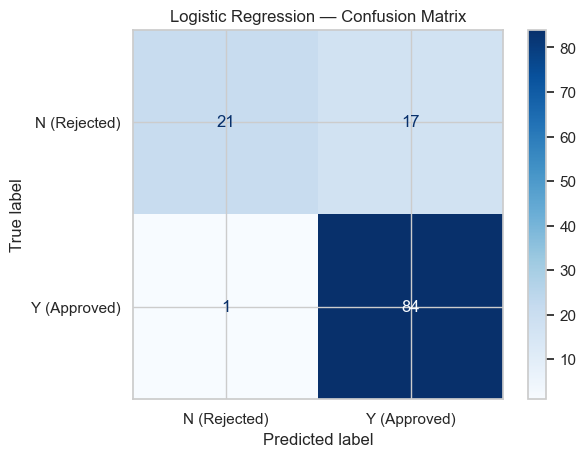

In [59]:
y_pred_log_final = grid_log.best_estimator_.predict(X_log_test_final)

print(classification_report(y_test_final, y_pred_log_final, target_names=['N (Rejected)', 'Y (Approved)']))

cm_log = confusion_matrix(y_test_final, y_pred_log_final)
ConfusionMatrixDisplay(cm_log, display_labels=['N (Rejected)', 'Y (Approved)']).plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()


### Business Implication

Logistic Regression xác định chính xác phần lớn các hồ sơ được phê duyệt và cung cấp trọng số rõ ràng cho từng biến đầu vào, giúp doanh nghiệp dễ dàng giải thích cơ sở ra quyết định với cơ quan quản lý hoặc kiểm toán.

Điểm hạn chế chính của mô hình là khả năng bỏ sót nhiều hồ sơ có rủi ro hơn so với các mô hình dựa trên cây được trình bày ở các phần tiếp theo.


## 8.2 Decision Tree Evaluation

### Business Question
Decision Tree dự đoán khả năng phê duyệt khoản vay trên các hồ sơ khách hàng mới (chưa từng được quan sát) hiệu quả như thế nào?

              precision    recall  f1-score   support

N (Rejected)       0.90      0.71      0.79        38
Y (Approved)       0.88      0.96      0.92        85

    accuracy                           0.89       123
   macro avg       0.89      0.84      0.86       123
weighted avg       0.89      0.89      0.88       123



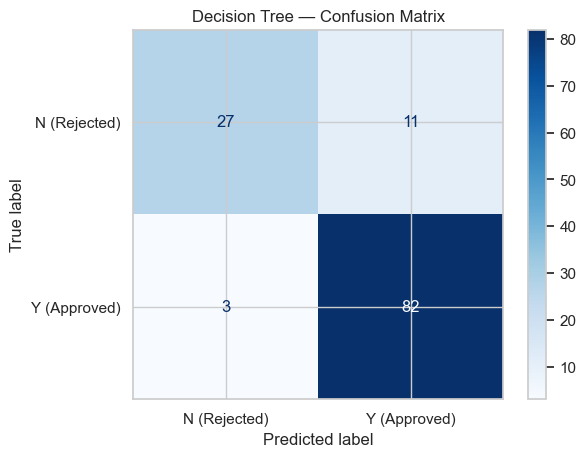

In [60]:
y_pred_tree_final = grid_tree.best_estimator_.predict(X_raw_test_final)

print(classification_report(y_test_final, y_pred_tree_final, target_names=['N (Rejected)', 'Y (Approved)']))

cm_tree = confusion_matrix(y_test_final, y_pred_tree_final)
ConfusionMatrixDisplay(cm_tree, display_labels=['N (Rejected)', 'Y (Approved)']).plot(cmap='Blues')
plt.title('Decision Tree — Confusion Matrix')
plt.show()


### Business Implication

Decision Tree đạt mức Precision và Accuracy cao nhất, cho thấy mô hình giúp giảm số lượng hồ sơ rủi ro bị phê duyệt sai. Các quy tắc quyết định của mô hình có thể được diễn giải trực tiếp bởi nhân viên tín dụng, giúp quá trình giải thích quyết định từ chối cho khách hàng trở nên minh bạch và dễ hiểu hơn.


## 8.3 Random Forest Evaluation

### Business Question
Random Forest dự đoán khả năng phê duyệt khoản vay trên các hồ sơ khách hàng mới (chưa từng được quan sát) hiệu quả như thế nào?

              precision    recall  f1-score   support

N (Rejected)       0.95      0.55      0.70        38
Y (Approved)       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



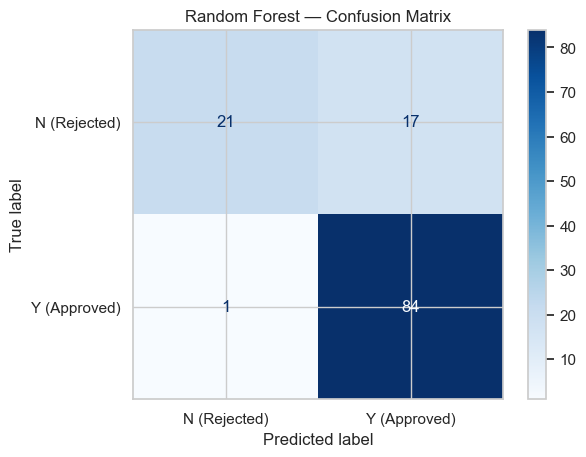

In [61]:
y_pred_rf_final = grid_rf.best_estimator_.predict(X_raw_test_final)

print(classification_report(y_test_final, y_pred_rf_final, target_names=['N (Rejected)', 'Y (Approved)']))

cm_rf = confusion_matrix(y_test_final, y_pred_rf_final)
ConfusionMatrixDisplay(cm_rf, display_labels=['N (Rejected)', 'Y (Approved)']).plot(cmap='Blues')
plt.title('Random Forest — Confusion Matrix')
plt.show()


### Business Implication

Random Forest có hiệu quả tương đương với Logistic Regression trên tập dữ liệu này và không cho thấy lợi thế rõ ràng về Accuracy so với Decision Tree. Giá trị chính của mô hình nằm ở cấu trúc hoạt động thay vì chỉ ở hiệu quả dự báo: bằng cách kết hợp kết quả từ nhiều cây quyết định, mô hình ít phụ thuộc hơn vào một biến đơn lẻ (`Credit_History`). Điều này có thể giúp mô hình trở nên ổn định hơn nếu chất lượng dữ liệu tín dụng thay đổi khi triển khai ở quy mô lớn trong tương lai.



## 8.4 Model Comparison

### Business Question
Mô hình nào có hiệu quả tổng thể tốt nhất trên tập Test?

In [62]:
model_comparison = pd.DataFrame({
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test_final, y_pred_log_final),
        'Precision': precision_score(y_test_final, y_pred_log_final),
        'Recall': recall_score(y_test_final, y_pred_log_final),
        'F1': f1_score(y_test_final, y_pred_log_final),
    },
    'Decision Tree': {
        'Accuracy': accuracy_score(y_test_final, y_pred_tree_final),
        'Precision': precision_score(y_test_final, y_pred_tree_final),
        'Recall': recall_score(y_test_final, y_pred_tree_final),
        'F1': f1_score(y_test_final, y_pred_tree_final),
    },
    'Random Forest': {
        'Accuracy': accuracy_score(y_test_final, y_pred_rf_final),
        'Precision': precision_score(y_test_final, y_pred_rf_final),
        'Recall': recall_score(y_test_final, y_pred_rf_final),
        'F1': f1_score(y_test_final, y_pred_rf_final),
    },
}).T.round(3)

model_comparison


,Accuracy,Precision,Recall,F1
Logistic Regression,0.85,0.83,0.99,0.90
Decision Tree,0.89,0.88,0.96,0.92
Random Forest,0.85,0.83,0.99,0.90


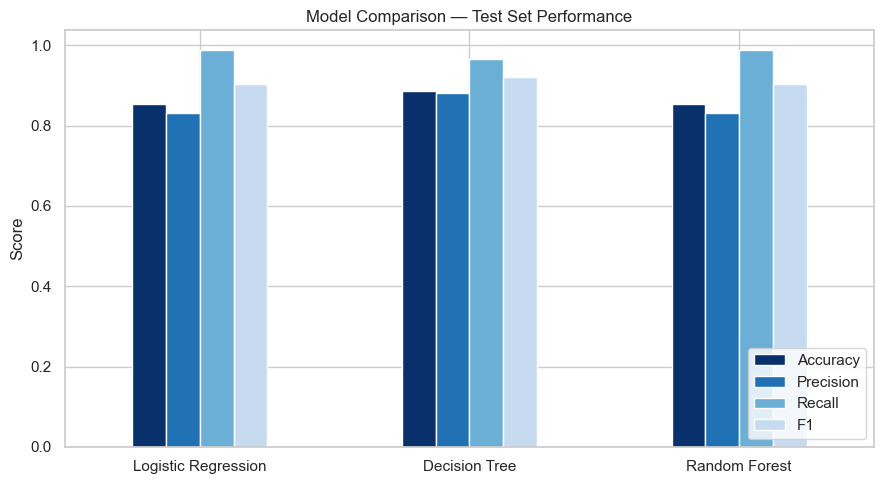

In [63]:
model_comparison.plot(
    kind='bar', figsize=(9, 5),
    color=['#08306b', '#2171b5', '#6baed6', '#c6dbef']
)
plt.title('Model Comparison — Test Set Performance')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### Business Insight

Decision Tree đạt hiệu quả tổng thể cao nhất trên tập Test với các chỉ số **Accuracy 0.886, Precision 0.882 và F1-score 0.921**, trong khi Logistic Regression vẫn là mô hình có khả năng diễn giải tốt nhất thông qua trọng số của từng biến.

Random Forest cho kết quả gần tương đương với Logistic Regression và chưa thể hiện ưu thế so với Decision Tree trên tập dữ liệu có quy mô tương đối nhỏ này. Tuy nhiên, mô hình có lợi thế về tính ổn định khi ít phụ thuộc vào một biến duy nhất (`Credit_History` chiếm khoảng 47% mức độ quan trọng so với khoảng 89% ở Decision Tree), điều này có thể trở nên quan trọng hơn khi mô hình được triển khai ở quy mô lớn.


## 8.5 Best Model Selection

### Business Question

Mô hình nào nên được Company X triển khai?

### Decision Matrix

| Business Strategy | Recommended Model | Reason |
| ---------------------------------------------------------- | ------------------- | ------------------------------------------------------------------------------------------------------------ |
| Minh bạch theo yêu cầu quản lý / kiểm toán                 | Logistic Regression | Trọng số của các biến dễ diễn giải và có thể giải thích rõ ràng với cơ quan quản lý.                         |
| Hỗ trợ nhân viên tín dụng / giải thích lý do từ chối       | Decision Tree       | Quy tắc ra quyết định trực quan, dễ hiểu, đồng thời đạt Accuracy và Precision cao nhất trên tập dữ liệu này. |
| Tự động hóa quy mô lớn, giảm phụ thuộc vào một biến đơn lẻ | Random Forest       | Cơ chế kết hợp nhiều cây giúp giảm mức độ phụ thuộc vào `Credit_History` (~47% so với ~89% ở Decision Tree). |

### Business Implication

Không có một mô hình "tốt nhất" cho mọi mục tiêu kinh doanh; mỗi mô hình phù hợp với một chiến lược triển khai khác nhau.

Với ưu tiên hiện tại của Company X là hỗ trợ nhân viên tín dụng bằng một công cụ có khả năng giải thích và độ chính xác cao trong việc sàng lọc hồ sơ, **Decision Tree** được khuyến nghị lựa chọn.

Trong trường hợp ưu tiên tính minh bạch với cơ quan quản lý, Logistic Regression sẽ phù hợp hơn. Khi Company X mở rộng sang xử lý tự động với khối lượng hồ sơ lớn, Random Forest có thể mang lại sự ổn định cao hơn trước những thay đổi về chất lượng dữ liệu tín dụng.


# 9. Business Recommendation

**Khuyến nghị 1 — Ưu tiên đánh giá khách hàng có lịch sử tín dụng tốt.**
`Credit_History` là biến dự báo quan trọng nhất trong cả ba mô hình, chiếm tới ~89% mức độ quan trọng của biến trong Decision Tree. Company X nên xem việc xác minh lịch sử tín dụng là bước đầu tiên trong quy trình sàng lọc hồ sơ. Các hồ sơ có lịch sử tín dụng bị thiếu hoặc không thể xác minh nên được chuyển sang quy trình kiểm tra thủ công thay vì tự động phê duyệt hoặc từ chối.

**Khuyến nghị 2 — Đánh giá khả năng chi trả dựa trên Loan-to-Income Ratio thay vì chỉ sử dụng Applicant Income.**
Chỉ sử dụng thu nhập của người đăng ký vay chưa phản ánh đầy đủ năng lực trả nợ của hộ gia đình. Các biến như `Loan_to_Income_Ratio` và `EMI`, kết hợp thông tin về khoản vay, thời hạn vay và tổng thu nhập hộ gia đình, cung cấp tín hiệu đáng tin cậy hơn về khả năng chi trả và nên được đưa vào quy trình sàng lọc tiêu chuẩn.

**Khuyến nghị 3 — Sử dụng mô hình học máy như công cụ hỗ trợ ra quyết định, không thay thế nhân viên tín dụng.**
Mô hình nên được sử dụng để sàng lọc và ưu tiên xử lý hồ sơ — tự động đẩy nhanh các trường hợp có mức độ tín nhiệm cao và cảnh báo các hồ sơ rủi ro hoặc thiếu thông tin để xem xét thêm. Tuy nhiên, quyết định phê duyệt cuối cùng, đặc biệt với các hồ sơ có giá trị lớn hoặc nằm ở vùng ranh giới, vẫn cần được thực hiện bởi nhân viên tín dụng.



# 10. Conclusion

- Hoàn thành toàn bộ quy trình CRISP-DM từ bước Business Understanding đến Model Evaluation.
- Xử lý dữ liệu thiếu bằng chiến lược điền khuyết chỉ dựa trên tập Train (Train-only imputation), giúp tránh hiện tượng rò rỉ dữ liệu sang tập Test.
- Xây dựng các biến phản ánh khả năng chi trả (`Total_Income`, `EMI`, `Loan_to_Income_Ratio`) nhằm thể hiện tốt hơn năng lực hoàn trả khoản vay của khách hàng.
- So sánh ba mô hình học máy gồm Logistic Regression, Decision Tree và Random Forest dựa trên các chỉ số Accuracy, Precision, Recall và F1-score.
- Lựa chọn Decision Tree là mô hình được khuyến nghị, đạt sự cân bằng giữa hiệu quả dự báo và khả năng diễn giải trong quy trình sàng lọc hồ sơ vay của Company X.



## Executive Summary
| Business Question         | Answer                     |
| ------------------------- | -------------------------- |
| Typical applicants        | Male, Married, Graduate    |
| Strongest approval factor | Credit History             |
| Best engineered features  | Loan-to-Income Ratio, EMI  |
| Best model                | Decision Tree             |
| Recommended use           | Support the loan pre-screening process by prioritizing applications for manual review, rather than replacing loan officers. |


# 11. Limitations & Future Work

## 11.1 Limitations

- Quy mô dữ liệu nhỏ (614 dòng), làm hạn chế mức độ tin cậy khi đánh giá khả năng tổng quát hóa của mô hình trên các hồ sơ khách hàng mới.
- Tập biến đầu vào còn hạn chế, chưa bao gồm các thông tin quan trọng như lịch sử việc làm, các khoản nợ hiện tại hoặc hành vi trả nợ sau khi giải ngân.
- Chưa có dữ liệu điểm tín dụng bên ngoài hoặc thông tin từ tổ chức tín dụng, ngoài biến nhị phân `Credit_History`.

## 11.2 Future Work

- Thu thập thêm dữ liệu lịch sử khách hàng và hành vi trả nợ theo thời gian để cải thiện khả năng học và dự báo của mô hình.
- Chuẩn hóa quy trình tiền xử lý thành `Pipeline` kết hợp với `ColumnTransformer` nhằm nâng cao khả năng triển khai trong môi trường thực tế.
- Thử nghiệm các mô hình Gradient Boosting như XGBoost để đánh giá khả năng cải thiện hiệu quả dự báo.
- Bổ sung phương pháp giải thích mô hình dựa trên SHAP nhằm cung cấp góc nhìn chi tiết theo từng hồ sơ khách hàng và hỗ trợ diễn giải mô hình độc lập với thuật toán.



#THE END